# Prosit 1: Allocating bed nets across Ghana's districts under uncertainty

**Problem statement.** We will allocate a fixed stock of bed nets across the 50 districts of Ghana's three northern regions, ranked by *unprotected malaria burden* (confirmed cases per person, scaled by the share of households without a net), measured from 2014–17 routine surveillance and the 2022 DHS household survey, to direct nets where exposure is highest and protection lowest. Where the evidence for a district is thin, the district gets the benefit of the doubt.

**How to read this notebook.** It runs top to bottom from a fresh clone (`data/` must be present; it is never committed). Every section starts with a plain-language explanation of *what* the step does and *why it exists*, then the code, then what the numbers mean. Markdown cells marked **Concept** are the beginner explanations; skip them on a second read.

### Framing: target, unit, metric

| | |
|---|---|
| **Core question** | Where should Ghana's limited ITNs go, and how confident can we be in the district-level estimates behind that decision? |
| **Target** (what we maximise) | Nets reaching people who are both exposed to malaria and not yet protected by a net. |
| **Unit** (what we decide) | Nets per district, for the 50 districts that have district-level case data. |
| **Metric** (how we rank) | Unprotected burden = confirmed cases per person × (1 − household net coverage), ranked on the **upper** bound of its 95% interval so thin evidence counts in a district's favour. |

**The four things the brief asks us to justify, and where each is answered.**

| Question | Short answer | Section |
|---|---|---|
| Which estimate did you use? | Confirmed cases per person 2014–17 (routine surveillance), modelled as Negative Binomial with a population offset; weighted DHS 2022 net ownership for coverage. | §2, §3, §4 |
| How uncertain is it? | α = 0.42 (heavy over-dispersion). District 95% intervals from a month bootstrap; survey intervals from a weighted cluster bootstrap, about twice as wide as the naive interval. | §3, §4, §6 |
| How did you avoid sampling bias and leakage? | Survey weights and cluster resampling; split before preprocessing; grouped and stratified splits; Pipeline fitted on train only; four leaks audited with before/after numbers. | §4, §7, §8, §9 |
| Which districts did you prioritise, and why? | Nabdam, then the Upper West block (Daffiama-Bussie-Issa, Wa, Lambussie-Karni, Sissala East…). High rate, lower coverage, wide intervals. | §11, §12 |

| # | Section | Prosit task |
|---|---|---|
| 1 | Setup and data loading | |
| 2 | Vital signs: what the counts look like | A1 |
| 3 | Poisson vs Negative Binomial | A2, A3 |
| 4 | The survey: weights, clusters, and honest confidence intervals | A4 |
| 5 | What is missing, and where the data is thin | B1 |
| 6 | Per-district uncertainty and imputation of missing months | A4, B2 |
| 7 | Train/test split, done before anything else | B4 |
| 8 | Preprocessing pipeline: imputation and encoding | B2, B3 |
| 9 | Leakage audit with before/after numbers | B4 |
| 10 | Count regression with district-level interventions | A3 |
| 11 | The allocation rule, its sensitivity, and equity | Framing, Equity |
| 12 | Maps and probability heatmaps | B1 |
| 13 | How much should we trust the data? | LO7 |
| 14 | Limitations, sources, declarations | LO7 |
| 15 | The experiment matrix: every lever, what it does, why we chose our route | all |


## 1. Setup

**Concept: reproducibility.** A grader will clone this repository into an empty folder, install `requirements.txt`, and run every cell in order. Nothing here may depend on a file that is not in the repo or in `data/`, on a cell being run twice, or on a random draw we did not seed. `RNG = np.random.default_rng(0)` fixes the random numbers so every bootstrap below gives the same answer on every machine.

The `data/` folder holds a licensed survey extract. It is in `.gitignore`. This notebook prints only aggregates, never household rows.

In [1]:
# ---- Imports: each library does one job in this notebook ----
from pathlib import Path                     # file paths that work the same on Mac, Windows and Linux
import itertools                             # standard-library helpers for loops (kept available for grid experiments)
import numpy as np                           # fast maths on arrays of numbers
import pandas as pd                          # tables (DataFrames): loading CSVs, grouping, summarising
import geopandas as gpd                      # pandas plus a geometry column, so a table can be drawn as a map
import matplotlib.pyplot as plt              # plotting
import statsmodels.api as sm                 # statistical models: Poisson and Negative Binomial fits live here
from scipy import stats                      # probability distributions (pmf, tail probabilities, quantiles)
from sklearn.compose import ColumnTransformer            # apply different preprocessing to different columns
from sklearn.impute import SimpleImputer                 # fill missing values with a mean/median
from sklearn.linear_model import LogisticRegression      # the classifier used in the supervised task
from sklearn.metrics import roc_auc_score                # the score we judge the classifier by
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, KFold, cross_val_score, train_test_split  # every kind of split we use
from sklearn.pipeline import Pipeline                    # chains preprocessing + model so they are always fitted together
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # turn categories into 0/1 columns; put numbers on one scale

# ---- Reproducibility and paths ----
RNG = np.random.default_rng(0)               # one seeded random-number generator: every bootstrap gives the same answer on every machine
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent  # repo root, whether Jupyter was started in the root or in notebooks/
DATA = ROOT / "data"                         # the git-ignored data folder
FIG, TAB = ROOT / "outputs/figures", ROOT / "outputs/tables"   # where figures and tables are written; aggregates only, safe to commit
FIG.mkdir(parents=True, exist_ok=True)       # create the figures folder if it is not there (a fresh clone has no outputs/)
TAB.mkdir(parents=True, exist_ok=True)       # same for the tables folder
def save(fig, name):                         # tiny helper so every figure is saved the same way
    fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")  # dpi=200 is sharp enough for slides; "tight" trims white margins

# ---- Display settings (cosmetic only) ----
pd.set_option("display.width", 160, "display.max_columns", 30, "display.float_format", "{:,.3f}".format)  # wide tables, 3 decimals, thousands separators
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})            # cleaner plots: no top/right border

# ---- Load the three course files ----
districts = pd.read_csv(DATA / "ghana_district_cases.csv")   # one row per district: case counts 2014-17 (the count data for Theme A)
survey = pd.read_csv(DATA / "ghana_mis_sample.csv")          # one row per household: DHS 2022 extract (CONFIDENTIAL: never print its rows)
regions = pd.read_csv(DATA / "ghana_region_malaria.csv")     # one row per region per survey year: official DHS figures with intervals
print("districts", districts.shape, "| survey households", survey.shape, "| region-year rows", regions.shape)  # (rows, columns) sanity check that everything loaded

districts (50, 12) | survey households (17933, 10) | region-year rows (76, 21)


**The three files and how they relate.** `districts` is one row per district: cumulative 2014–17 case counts for the 50 districts of Northern, Upper East and Upper West. `survey` is one row per household from the 2022 DHS, all 16 regions, with no district column. `regions` is one row per region per survey year with the *official* prevalence and net-ownership figures, including published confidence intervals. The only key the district file and the survey share is the 16-region code, so any statement that uses both is a region-level statement.

**The data as delivered differs from the brief, and that shapes what follows.** The brief describes `ghana_district_cases.csv` as carrying covariates (rainfall, temperature, elevation, distance to water) and the MIS subset as carrying parasitaemia and net usage. The package we received, documented in `data/data_dictionary.md`, has neither: the district file holds case counts, population and one regional net-coverage figure; the survey extract holds net ownership, wealth, residence and weights, de-identified to **region** (no district column) and with no malaria test result. We use real data only, so we did not invent the missing columns. Consequences: the count models use region and IRS, not climate covariates (§10); the bootstrap of a *prevalence* uses the official regional RDT figures and child counts (§4); and the cluster-bootstrap lesson is demonstrated on net ownership, the one household-level outcome the extract does carry (§4).

In [2]:
# Lookup from the DHS region code (column hv024, 1-16) to the region's name as spelled in the boundary file.
# Needed because the survey stores regions as numbers and the map stores them as names.
REGION_NAMES = {1: "Western", 2: "Central", 3: "Greater Accra", 4: "Volta", 5: "Eastern", 6: "Ashanti",
                7: "Western North", 8: "Ahafo", 9: "Bono", 10: "Bono East", 11: "Oti", 12: "Northern",
                13: "Savannah", 14: "Northern East", 15: "Upper East", 16: "Upper West"}  # hv024 -> admin1 name in the boundary file
NORTH = [12, 15, 16]  # regions with district-level counts
# The quantity we actually care about: cases per person. Dividing by population makes big and small districts comparable.
districts["rate"] = districts.positive_cases / districts.mean_population  # cases per person over 4 years
districts.head()                             # show the first 5 rows (public surveillance data, fine to display)

,district,region_name,region_code,year_start,year_end,months_reported,suspected_cases,tested_cases,positive_cases,mean_population,positive_per_100k,net_coverage_pct,rate
0,Bawku,Upper East Region,15,2014,2017,48,1178349,931717,375349,"109,220.300","343,662.300",79.560,3.437
1,Bawku West,Upper East Region,15,2014,2017,48,763380,637217,330111,"104,485.800","315,938.620",79.560,3.159
2,Binduri,Upper East Region,15,2014,2017,48,349083,309419,195412,"68,482.800","285,344.820",79.560,2.853
3,Bole,Northern Region,12,2014,2017,48,606409,290958,191586,"70,912.200","270,173.450",67.690,2.702
4,Bolgatanga,Upper East Region,15,2014,2017,48,1193785,1093550,589849,"146,647.900","402,221.140",79.560,4.022


## 2. Vital signs (A1)

**Concept: look before you model.** Every model makes assumptions about the shape of the data. The cheapest way to find out which assumptions are false is to compute the mean, median and variance and draw a histogram. Three things to read off:

- **Skew.** If the mean is well above the median, a few large values pull the average up. The histogram will have a long right tail.
- **Variance-to-mean ratio.** For counts this is the single most important number. The Poisson distribution forces variance = mean, so a ratio far from 1 rules Poisson out before you fit anything.
- **Zeros.** Excess zeros need special models. None here means that whole family is irrelevant.

In [3]:
def describe_counts(s):
    # One function so the same "vital signs" are computed identically for any column we pass in.
    return pd.Series({"n": len(s),                       # how many districts
                      "mean": s.mean(),                  # the average
                      "median": s.median(),              # the middle value; mean > median signals right skew
                      "variance": s.var(),               # spread around the mean (sample variance)
                      "var/mean": s.var() / s.mean(),    # THE over-dispersion check: a Poisson needs this to be about 1
                      "min": s.min(), "max": s.max(),    # range, to spot extreme districts
                      "zeros": (s == 0).sum()})          # count of zeros: decides whether zero-inflated models are even relevant

# Run it on the raw counts and on the per-person rate, side by side, to see whether dividing by population removes the skew.
summary = pd.DataFrame({"positive_cases": describe_counts(districts.positive_cases),
                        "rate (cases/person)": describe_counts(districts.rate)})
summary                                      # last line of a cell is displayed as a table

,positive_cases,rate (cases/person)
n,50.000,50.000
mean,"195,639.620",2.345
median,"158,425.000",2.151
variance,"15,100,003,891.506",2.136
var/mean,"77,182.750",0.911
min,"41,612.000",0.370
max,"589,849.000",7.134
zeros,0.000,0.000


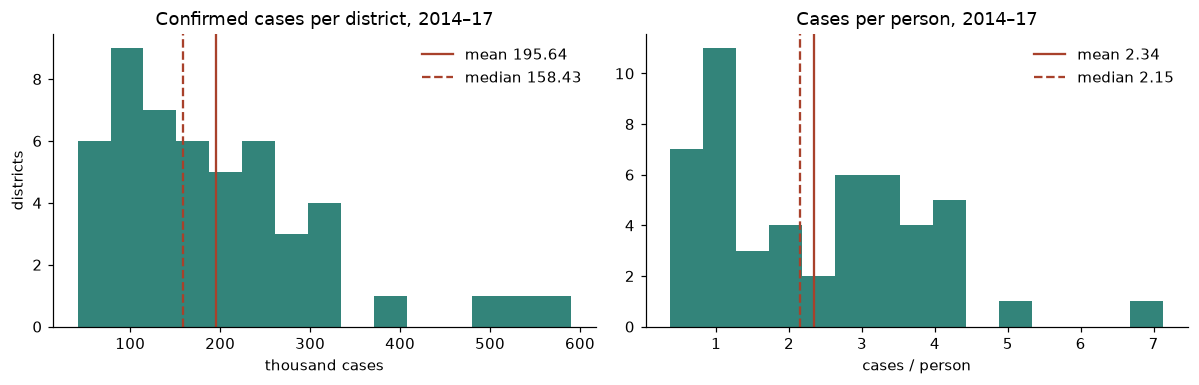

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))                                   # one figure, two panels side by side
ax[0].hist(districts.positive_cases / 1e3, bins=15, color="#0F6E63", alpha=.85)    # left: histogram of raw counts, in thousands so the axis is readable
ax[0].set(title="Confirmed cases per district, 2014–17", xlabel="thousand cases", ylabel="districts")   # title and axis labels, so the chart can be read without the surrounding text
ax[1].hist(districts.rate, bins=15, color="#0F6E63", alpha=.85)                    # right: histogram of cases per person
ax[1].set(title="Cases per person, 2014–17", xlabel="cases / person")   # title and axis labels, so the chart can be read without the surrounding text
for a, s in zip(ax, [districts.positive_cases / 1e3, districts.rate]):            # for each panel and the data drawn in it...
    a.axvline(s.mean(), color="#A8412B", label=f"mean {s.mean():,.2f}")            # ...solid line at the mean
    a.axvline(s.median(), color="#A8412B", ls="--", label=f"median {s.median():,.2f}")  # ...dashed line at the median; the gap between them IS the skew
    a.legend(frameon=False)                                                        # show the labels, without a box
plt.tight_layout()                                                                 # stop labels overlapping
save(fig, "01_histograms")                                                         # write the PNG for the slides

**What the numbers say.** Both distributions are right-skewed: mean above median, long tail to the right. The variance-to-mean ratio of the raw counts is in the tens of thousands. A Poisson distribution with this mean would have a standard deviation of about 440 cases; the actual standard deviation is about 123,000. Dividing by population does not remove the skew; some districts genuinely have several times the burden of others. That is the thing we want to find, not an artefact to smooth away.

> **Answer (A1).** Yes, the counts are right-skewed: mean 195,640 against median 158,425, with a tail out to 589,849. Yes, they are over-dispersed, massively: variance is about 77,000 times the mean, where a Poisson requires a ratio of 1. *Source: `ghana_district_cases.csv`, Ghana Health Service routine surveillance 2014–17.*

## 3. Poisson versus Negative Binomial (A2, A3)

**Concept: what a count model is.** A count model says "the number of cases in district *i* is a random draw from a distribution whose mean depends on district *i*". The Poisson is the default: one parameter λ, and both mean and variance equal λ. The Negative Binomial (NB) adds a second parameter α so that variance = μ + αμ². With α = 0 it *is* the Poisson; larger α means more spread around the mean.

**Concept: the offset.** Big districts have more cases just by being big. We want the model to describe a *rate*. If we add log(population) to the linear predictor with its coefficient fixed at 1, then E[cases] = population × e^β, and β describes the rate. That fixed term is called an offset.

**Predict before you fit.** Rearranging the NB variance formula: α ≈ (var/μ − 1)/μ. We compute that from the raw data first and write it down. If the fitted α lands near it, we understand what the model is doing.

In [5]:
y = districts.positive_cases.values                  # the response: confirmed cases per district, as a plain array
offset = np.log(districts.mean_population.values)    # log(population). Added with coefficient fixed at 1, it makes the model describe a RATE
X0 = np.ones((len(y), 1))  # intercept only: "all districts share one rate, plus noise"

# Predict alpha BEFORE fitting, from the NB variance formula var = mu + alpha*mu^2  =>  alpha = (var/mu - 1)/mu.
# If the fit lands near this, we understand what the model is doing.
alpha_predicted = (y.var() / y.mean() - 1) / y.mean()
poisson = sm.GLM(y, X0, family=sm.families.Poisson(), offset=offset).fit()   # Poisson fit: one parameter, variance forced equal to the mean
nb = sm.NegativeBinomial(y, X0, offset=offset).fit(disp=0)                   # Negative Binomial fit: adds alpha for extra variance. disp=0 silences the optimiser log
alpha_hat = nb.params[-1]                            # statsmodels stores alpha as the LAST fitted parameter
alpha_ci = nb.conf_int()[-1]                         # its 95% confidence interval (last row of the interval table)

print(f"alpha predicted from var/mean: {alpha_predicted:.3f}")   # the value we predicted from the raw data before fitting
print(f"alpha fitted:                  {alpha_hat:.3f}   95% CI [{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]")   # the fitted value and its 95% interval: compare with the prediction above
# Comparison table. AIC: lower is better, a gap above ~10 is decisive. llf = log-likelihood: higher is better.
pd.DataFrame({"Poisson": [poisson.aic, poisson.llf, np.nan], "Negative Binomial": [nb.aic, nb.llf, alpha_hat]},
             index=["AIC", "log-likelihood", "alpha"])

alpha predicted from var/mean: 0.387
alpha fitted:                  0.417   95% CI [0.263, 0.570]


,Poisson,Negative Binomial
AIC,"4,419,517.333","1,309.358"
log-likelihood,"-2,209,757.667",-652.679
alpha,NaN,0.417


**Concept: AIC.** The Akaike Information Criterion scores a fitted model by how well it explains the data, with a penalty for each parameter. Lower is better. A difference of 10 is decisive. Here the difference is in the millions, which tells you the Poisson is not slightly worse, it is the wrong family.

**The number that goes on the slide** is not the AIC. It is the probability each model gives to the district with the most cases, which we actually observed.

In [6]:
mu = poisson.predict(X0, offset=offset)            # Poisson mean per district (same rate, scaled by population)
i = y.argmax()                                      # position of the district with the MOST cases: the hardest one for a model to explain
# sf = "survival function" = P(Y > k). Passing y-1 turns it into P(Y >= y): how likely is a count at least this big?
p_pois = stats.poisson.sf(y[i] - 1, mu[i])          # P(Y >= observed)
r = 1 / alpha_hat                                   # scipy describes the NB by a "size" r = 1/alpha ...
p_nb = stats.nbinom.sf(y[i] - 1, r, r / (r + mu[i]))  # ... and a probability p = r/(r+mu); together they give mean mu and variance mu + alpha*mu^2
print(f"{districts.district[i]}: observed {y[i]:,} cases, model mean {mu[i]:,.0f}")   # which district it is, what we observed, and what the model expected
print(f"P(cases >= observed) under Poisson: {p_pois:.2e}")   # ~0: the Poisson says the district we observed cannot exist
print(f"P(cases >= observed) under NB:      {p_nb:.3f}")     # a plausible tail probability

Bolgatanga: observed 589,849 cases, model mean 299,554
P(cases >= observed) under Poisson: 0.00e+00
P(cases >= observed) under NB:      0.083


**A2 exactly as the brief words it: λ estimated as the sample mean.** Before any offset, the simplest possible Poisson takes λ = the mean count. A Poisson with λ ≈ 195,640 has standard deviation √λ ≈ 442, so it predicts that essentially every district lies within about ±1,300 cases of the mean. The cell counts how many actually do.

**Why the mean is the right estimate of λ (the maximum-likelihood derivation).** For counts $y_1,\dots,y_n$ assumed Poisson with a common rate λ, the likelihood is $L(\lambda)=\prod_i e^{-\lambda}\lambda^{y_i}/y_i!$, so the log-likelihood is $\ell(\lambda) = -n\lambda + \left(\sum_i y_i\right)\log\lambda - \sum_i \log y_i!$. Differentiate and set to zero: $\ell'(\lambda) = -n + \sum_i y_i/\lambda = 0 \Rightarrow \hat\lambda = \frac{1}{n}\sum_i y_i = \bar y$. The second derivative, $-\sum_i y_i/\lambda^2$, is negative, so this is a maximum. The best-fitting Poisson is therefore the one whose rate is the sample mean, and since a Poisson's variance also equals λ, the model has no freedom left to match the spread. That is the whole reason it fails here. The Negative Binomial arises when λ itself varies between districts (a Gamma-distributed rate): mixing Poissons over that Gamma gives variance $\mu + \alpha\mu^2$, with α the variance of the rate multiplier.

lambda = mean = 195,640;  Poisson sd = 442;  observed sd = 122,882
districts inside the Poisson's ±3 sd band: 2 of 50


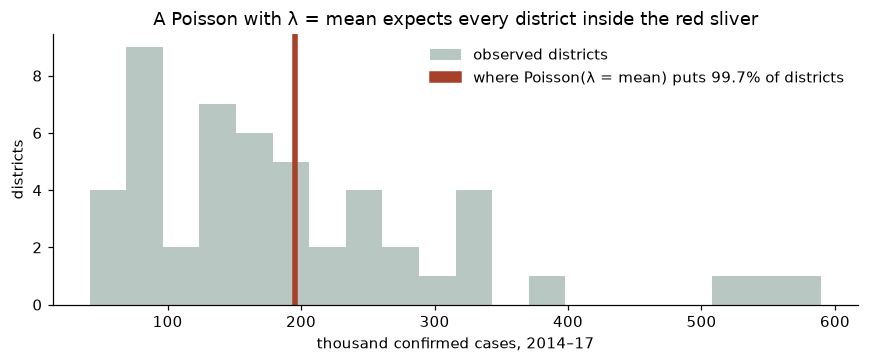

In [7]:
lam_simple = y.mean()                                # A2 as the brief words it: the Poisson rate lambda estimated by the sample mean (its MLE)
band = 3 * np.sqrt(lam_simple)                       # a Poisson's sd is sqrt(lambda); +/-3 sd holds ~99.7% of what it expects to see
inside = int(((y > lam_simple - band) & (y < lam_simple + band)).sum())   # how many real districts actually fall inside that band
print(f"lambda = mean = {lam_simple:,.0f};  Poisson sd = {np.sqrt(lam_simple):,.0f};  observed sd = {y.std(ddof=1):,.0f}")  # ddof=1 = sample sd
print(f"districts inside the Poisson's ±3 sd band: {inside} of {len(y)}")   # how many of the 50 districts the Poisson's expected range actually contains

fig, ax = plt.subplots(figsize=(8, 3.4))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
ax.hist(y / 1e3, bins=20, color="#B9C7C3", label="observed districts")               # what the data looks like
ax.axvspan((lam_simple - band) / 1e3, (lam_simple + band) / 1e3, color="#A8412B",     # the thin red band: where the Poisson says districts should be
           label="where Poisson(λ = mean) puts 99.7% of districts")
ax.set(title="A Poisson with λ = mean expects every district inside the red sliver", xlabel="thousand confirmed cases, 2014–17", ylabel="districts")   # title and axis labels, so the chart can be read without the surrounding text
ax.legend(frameon=False)   # draw the legend (the key to colours and line styles), without a box around it
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "02_poisson_lambda_mean")   # write the figure to outputs/figures so the slides can use it

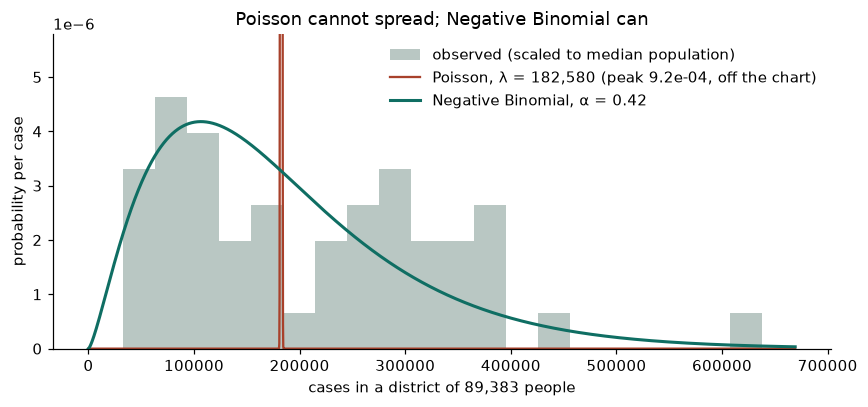

In [8]:
# Overlay both fitted distributions on the histogram of per-person rates (rate = cases / population).
# Each district has its own population, so we compare the *rate* implied by the fits, drawn for a typical population.
pop_typical = np.median(districts.mean_population)             # a "typical" district size, so both curves can be drawn on one axis
lam = pop_typical * np.exp(poisson.params[0])                  # expected cases in that district: population x fitted rate (exp undoes the log link)
grid = np.arange(0, int(districts.rate.max() * pop_typical * 1.05), 250)   # x-values at which to evaluate the curves, a little past the largest district
pmf_pois = stats.poisson.pmf(grid, lam)                        # Poisson probability of each count on the grid
pmf_nb = stats.nbinom.pmf(grid, r, r / (r + lam))              # Negative Binomial probability, same mean, with the fitted alpha
fig, ax = plt.subplots(figsize=(8, 3.8))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
counts, edges, _ = ax.hist(districts.rate * pop_typical, bins=20, density=True, color="#B9C7C3",   # data rescaled to the typical population;
                           label="observed (scaled to median population)")                          # density=True puts bars on the same scale as the curves
ax.plot(grid, pmf_pois, color="#A8412B", label=f"Poisson, λ = {lam:,.0f} (peak {pmf_pois.max():.1e}, off the chart)")   # a needle-thin spike
ax.plot(grid, pmf_nb, color="#0F6E63", lw=2, label=f"Negative Binomial, α = {alpha_hat:.2f}")                            # a wide curve that covers the data
ax.set(title="Poisson cannot spread; Negative Binomial can", xlabel=f"cases in a district of {pop_typical:,.0f} people",
       ylabel="probability per case", ylim=(0, counts.max() * 1.25))   # cap the y-axis at the histogram's height; otherwise the Poisson spike flattens everything else
ax.legend(frameon=False)   # draw the legend (the key to colours and line styles), without a box around it
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "03_poisson_vs_nb")   # write the figure to outputs/figures so the slides can use it

**Reading the plot.** The Poisson is a spike: with a mean of ~200,000 its standard deviation is only ~440, so it is invisible next to the real spread. The NB curve covers the histogram. The Poisson gives the largest observed district a probability of zero to machine precision. A model that says the data you are holding cannot exist is not a model of the data.

**What we do not fit.** Zero-inflated models: there are no zero-count districts (§2). Quasi-Poisson: it keeps the Poisson mean and scales standard errors by a dispersion factor φ = Pearson χ²/df, which here is about 90,000, meaning standard errors inflated 300×. It has no likelihood, so it cannot sit in the AIC table. One sentence is enough.

> **Answer (A2).** No. A Poisson with λ = mean matches the *centre* of the data and nothing else. It fails on spread: it expects all 50 districts inside a band about 2,650 cases wide; only 2 of 50 are, and the districts actually range over more than half a million. It assigns probability zero to the largest district we observed.
>
> **Answer (A3).** α = 0.417 (95% CI 0.263 to 0.570), close to the 0.387 we predicted from the raw variance before fitting. α is the extra-variance parameter: variance = μ + αμ². The NB fits far better: AIC 1,309 against 4,419,517, the mean–variance relationship now matches, and the largest district gets a plausible 8% tail probability instead of zero. It fits better because districts genuinely differ in climate, health systems and reporting, and the NB has a parameter for that heterogeneity while the Poisson does not. *Q–Q plot omitted; the brief marks it optional.*

## 4. The survey: weights, clusters, and honest confidence intervals (A4)

**Concept: how the DHS was collected.** A national survey cannot pick households at random across the whole country; enumerators would spend all their time travelling. Instead it picks *clusters* (small areas, 618 of them), then surveys about 30 households inside each. Households in one cluster share a village, a clinic and a net campaign, so they resemble each other. 17,933 households therefore carry less information than 17,933 independent draws would.

**Concept: sampling weights.** The survey deliberately over-samples small regions so every region has enough households to report on. Each household carries a weight: how many real households it stands for. A simple average of any survey column is the average of the *sample*, which is not the population. The weighted average is.

In [9]:
def weighted_mean(df, col="has_net"):
    # Survey-weighted average: each household counts in proportion to how many real households it stands for.
    return (df[col] * df.sample_weight).sum() / df.sample_weight.sum()

# For each region: sample size, number of clusters, and net ownership computed the naive way and the weighted way.
by_region = survey.groupby("region").apply(lambda g: pd.Series({
    "households": len(g),                              # households surveyed in this region
    "clusters": g.cluster.nunique(),                   # how many clusters they came from: the TRUE number of independent sampling units
    "net ownership unweighted": g.has_net.mean(),      # plain average of the sample (describes the sample, not the population)
    "net ownership weighted": weighted_mean(g)}),      # weighted average (the honest population estimate)
    include_groups=False)                              # do not pass the grouping column into the function (pandas >= 2.2 behaviour)
by_region.index = by_region.index.map(REGION_NAMES)   # show region names instead of codes
# Official 2022 DHS figures. "x == x" is False only for missing values, so this keeps rows that HAVE a 16-region code
# (it drops the pre-2022 aggregate rows). Indexed by region code so rows can be looked up with .loc[code].
official = regions.query("survey_year == 2022 and hv024_16region == hv024_16region").set_index("hv024_16region")
by_region["DHS official %"] = official.net_ownership_pct.rename(REGION_NAMES) / 100   # published figure next to ours: our correctness check
print(f"National net ownership: unweighted {survey.has_net.mean():.3f}, weighted {weighted_mean(survey):.3f}")   # the survey-design effect in one line: sample average vs population estimate
by_region.round(3)   # display the table (the last line of a cell is shown automatically)

National net ownership: unweighted 0.710, weighted 0.668


,households,clusters,net ownership unweighted,net ownership weighted,DHS official %
region,,,,,
Western,"1,087.000",37.000,0.643,0.640,0.640
Central,"1,160.000",40.000,0.676,0.673,0.673
Greater Accra,"1,387.000",48.000,0.507,0.488,0.488
Volta,"1,082.000",37.000,0.823,0.824,0.818
Eastern,"1,216.000",41.000,0.705,0.703,0.702
Ashanti,"1,397.000",48.000,0.661,0.662,0.660
Western North,"1,061.000",37.000,0.764,0.772,0.770
Ahafo,"1,062.000",36.000,0.797,0.798,0.798
Bono,"1,030.000",36.000,0.729,0.727,0.726


**Reading the table.** The weighted figure matches the official DHS number in every region to within rounding. That is the check that the weights are being applied correctly. The unweighted figure is off by a point or two per region and by four points nationally.

**Concept: the bootstrap.** To learn how much an estimate would move if the survey were repeated, we simulate repeating it: draw a new sample *from our own data, with replacement*, recompute the estimate, and do that 2,000 times. The middle 95% of the recomputed values is the confidence interval. The question is *what* to resample. If the survey picked clusters, resample clusters.

In [10]:
def bootstrap_cis(df, B=2000, rng=RNG):
    # Four ways to put a 95% interval on net ownership for the households in df. B = number of bootstrap resamples.
    # Precompute per-cluster totals so each bootstrap draw is a vectorised index operation.
    c = df.groupby("cluster").agg(n=("has_net", "size"),      # households in the cluster
                                  s=("has_net", "sum"),       # how many of them own a net
                                  ws=("sample_weight", lambda w: (w * df.loc[w.index, "has_net"]).sum()),  # weighted count of net owners
                                  w=("sample_weight", "sum")) # total weight of the cluster
    k = len(c)                                                # number of clusters
    p = df.has_net.mean()                                     # the plain sample proportion
    idx_c = rng.integers(0, k, (B, k))                       # resample clusters
    idx_h = rng.integers(0, len(df), (B, len(df)))           # resample households (wrong, for comparison)
    hh = df.has_net.values                                    # the 0/1 outcomes as an array, for fast indexing
    return pd.DataFrame({
        # 1. Textbook formula p +/- 1.96*sqrt(p(1-p)/n): assumes every household is independent.
        "normal approx (iid)": [p - 1.96 * np.sqrt(p * (1 - p) / len(df)), p + 1.96 * np.sqrt(p * (1 - p) / len(df))],
        # 2. Simple bootstrap: redraw households with replacement. Same (wrong) independence assumption.
        "simple bootstrap (households)": np.percentile(hh[idx_h].mean(1), [2.5, 97.5]),
        # 3. Cluster bootstrap: redraw WHOLE clusters, because that is how the survey was actually sampled.
        "cluster bootstrap": np.percentile(c.s.values[idx_c].sum(1) / c.n.values[idx_c].sum(1), [2.5, 97.5]),
        # 4. Weighted cluster bootstrap: whole clusters, with the survey weights carried through. The honest one.
        "weighted cluster bootstrap": np.percentile(c.ws.values[idx_c].sum(1) / c.w.values[idx_c].sum(1), [2.5, 97.5]),
    }, index=["low", "high"]).T.assign(width=lambda t: t.high - t.low)   # one row per method; width = high - low is what we compare

northern = survey[survey.region == 12]               # households in Northern region (code 12)
ci_table = bootstrap_cis(northern)                   # run all four methods on them
print(f"Northern region: {len(northern):,} households in {northern.cluster.nunique()} clusters; "   # context for the table: sample size, clusters, and our estimate next to the official figure
      f"weighted estimate {weighted_mean(northern):.3f}, DHS official {official.loc[12, 'net_ownership_pct']/100:.3f}")
ci_table.round(3)   # display the table (the last line of a cell is shown automatically)

Northern region: 1,137 households in 39 clusters; weighted estimate 0.677, DHS official 0.676


,low,high,width
normal approx (iid),0.634,0.689,0.055
simple bootstrap (households),0.635,0.690,0.055
cluster bootstrap,0.599,0.720,0.120
weighted cluster bootstrap,0.614,0.733,0.118


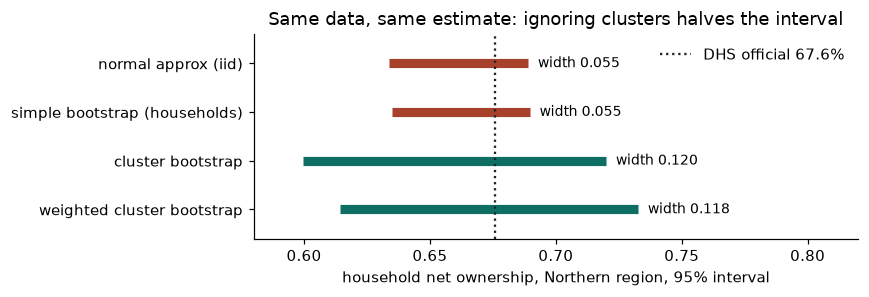

In [11]:
fig, ax = plt.subplots(figsize=(8, 2.8))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
colors = ["#A8412B", "#A8412B", "#0F6E63", "#0F6E63"]                 # red = methods that ignore clusters, green = methods that respect them
for k, (name, row) in enumerate(ci_table.iloc[::-1].iterrows()):     # reversed so the first method is drawn at the top of the chart
    ax.plot([row.low, row.high], [k, k], color=colors[::-1][k], lw=6, solid_capstyle="butt")   # one horizontal bar per interval
    ax.text(row.high + .004, k, f"width {row.width:.3f}", va="center", fontsize=9)             # print its width beside it
ax.axvline(official.loc[12, "net_ownership_pct"] / 100, color="#1B2426", ls=":", label="DHS official 67.6%")   # the published figure, for reference
ax.set_yticks(range(4))                              # one tick per method
ax.set_yticklabels(ci_table.index[::-1])             # label the ticks with the method names
ax.set_xlim(.58, .82)                                # room on the right for the width labels and legend
ax.set_ylim(-.6, 3.6)                                # a little padding above and below the bars
ax.set(title="Same data, same estimate: ignoring clusters halves the interval", xlabel="household net ownership, Northern region, 95% interval")   # title and axis labels, so the chart can be read without the surrounding text
ax.legend(frameon=False, loc="upper right")   # draw the legend (the key to colours and line styles), without a box around it
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "04_bootstrap_widths")   # write the figure to outputs/figures so the slides can use it
ci_table.round(4).to_csv(TAB / "bootstrap_ci_northern.csv")   # save the numbers behind the figure

**Reading the table.** The two methods that ignore clusters agree with each other and are about half as wide as the two that respect clusters. Same data, same estimate, interval doubles. The narrow interval is not "more precise"; it is wrong, because it counts each village's households as independent evidence. The ratio of the cluster-bootstrap variance to the naive variance is the **design effect**; for this region it is around 5, meaning 1,137 clustered households are worth about 230 independent ones.

Run it for every region, so we can see which regions are thin.

In [12]:
rows = []                                            # one dictionary per region, turned into a table at the end
for code_, name in REGION_NAMES.items():             # repeat the bootstrap for all 16 regions
    g = survey[survey.region == code_]               # this region's households
    t = bootstrap_cis(g, B=1000)                     # 1000 resamples is enough here and keeps the notebook quick
    rows.append({"region": name, "households": len(g), "clusters": g.cluster.nunique(),
                 "weighted net ownership": weighted_mean(g),
                 "CI low": t.loc["weighted cluster bootstrap", "low"], "CI high": t.loc["weighted cluster bootstrap", "high"],
                 "CI width": t.loc["weighted cluster bootstrap", "width"],
                 # Design effect = how many times larger the true variance is than the naive one.
                 # Interval width is proportional to the standard error, and variance = se^2, hence the squared ratio of widths.
                 "design effect": (t.loc["cluster bootstrap", "width"] / t.loc["normal approx (iid)", "width"]) ** 2})
region_ci = pd.DataFrame(rows).set_index("region")   # turn the list of dictionaries into a table, one row per region
region_ci.round(3).sort_values("CI width", ascending=False)   # widest interval first = least certain region first

,households,clusters,weighted net ownership,CI low,CI high,CI width,design effect
region,,,,,,,
Northern,1137,39,0.677,0.613,0.738,0.126,5.246
Western,1087,37,0.640,0.588,0.694,0.106,3.116
Northern East,1034,36,0.628,0.572,0.677,0.106,2.595
Central,1160,40,0.673,0.625,0.726,0.101,3.448
Bono East,1054,36,0.754,0.703,0.800,0.097,3.117
Upper West,1061,37,0.698,0.649,0.745,0.096,2.962
Eastern,1216,41,0.703,0.656,0.747,0.091,3.158
Savannah,1047,37,0.791,0.745,0.833,0.088,3.033
Upper East,1070,37,0.796,0.747,0.834,0.087,1.894


**The undersampled rural case.** The brief asks for an *undersampled rural district*. The survey extract has no district column (it is de-identified to region), so the finest honest unit is the **rural households of one region**. Restricting to rural households cuts the number of clusters, which is exactly what "undersampled" means for a cluster survey: fewer independent units, wider interval. The indicator is household net ownership; the extract carries no parasitaemia test result, so prevalence itself cannot be bootstrapped from it. Official RDT prevalence with DHS's own design-based intervals is in `ghana_region_malaria.csv` and is mapped in §12.

In [13]:
rows = []   # empty list; one dictionary of results per region is appended, then it becomes a table
for code_ in [12, 13, 14, 15, 16]:                       # the northern belt
    # RURAL households only: fewer clusters per region = "under-sampled", so intervals must widen.
    g = survey[(survey.region == code_) & (survey.residence == "rural")]
    t = bootstrap_cis(g, B=2000)   # all four interval methods on these households
    rows.append({"rural households of": REGION_NAMES[code_], "households": len(g), "clusters": g.cluster.nunique(),   # record this group's sample size, estimate and interval widths
                 "weighted net ownership": weighted_mean(g),
                 "naive width": t.loc["normal approx (iid)", "width"], "simple bootstrap width": t.loc["simple bootstrap (households)", "width"],
                 "weighted cluster width": t.loc["weighted cluster bootstrap", "width"]})
rural_ci = pd.DataFrame(rows).set_index("rural households of")   # turn the list of dictionaries into a table, one row per region
rural_ci["too narrow by"] = rural_ci["weighted cluster width"] / rural_ci["naive width"]   # how many times too narrow the naive interval is
rural_ci.round(3).to_csv(TAB / "bootstrap_ci_rural.csv")   # save the table to outputs/tables (aggregates only)
rural_ci.round(3)   # display the table (the last line of a cell is shown automatically)

,households,clusters,weighted net ownership,naive width,simple bootstrap width,weighted cluster width,too narrow by
rural households of,,,,,,,
Northern,582,20,0.760,0.071,0.070,0.140,1.971
Savannah,657,23,0.835,0.058,0.058,0.102,1.773
Northern East,634,22,0.678,0.074,0.076,0.119,1.611
Upper East,692,24,0.828,0.058,0.056,0.075,1.303
Upper West,701,24,0.713,0.067,0.066,0.110,1.643


**Bootstrapping a malaria prevalence.** The regional file gives, for the 2022 DHS, the RDT prevalence among children 6–59 months, the number of children actually tested, and DHS's own design-based 95% interval. Resampling *n* tested children with replacement from a sample in which a share *p* were positive is exactly a Binomial(*n*, *p*) draw, so we can run the **simple bootstrap** the brief offers as the fallback, then compare it with the official interval, which accounts for clusters and weights. The ratio of the two widths shows how much ignoring the design narrows the interval.

In [14]:
rows = []   # empty list; one dictionary of results per region is appended, then it becomes a table
for code_ in [12, 13, 14, 15, 16]:                   # the same five northern-belt regions
    r_ = official.loc[code_]                         # this region's official 2022 DHS row
    # n = children actually tested for malaria (the sample size); p = share who tested positive, as a proportion
    n, p = int(r_.n_children_tested_rdt_unweighted), r_.rdt_prevalence_pct / 100
    # Simple bootstrap of a proportion: drawing n children with replacement from a sample with positive share p
    # is exactly a Binomial(n, p) draw. Do it 5000 times, convert to proportions, take the middle 95%.
    lo, hi = np.percentile(RNG.binomial(n, p, 5000) / n, [2.5, 97.5])
    # DHS's own published interval (low, high), which DOES account for clusters and weights
    o_lo, o_hi = r_.rdt_prevalence_pct_ci_low / 100, r_.rdt_prevalence_pct_ci_high / 100
    rows.append({"region": REGION_NAMES[code_], "children tested": n, "RDT prevalence": p,
                 "simple bootstrap low": lo, "simple bootstrap high": hi, "simple width": hi - lo,
                 "official DHS low": o_lo, "official DHS high": o_hi, "official width": o_hi - o_lo,
                 "too narrow by": (o_hi - o_lo) / (hi - lo)})   # official width / simple width: the cost of ignoring the survey design
prev_ci = pd.DataFrame(rows).set_index("region")   # turn the list of dictionaries into a table, one row per region
prev_ci.round(3).to_csv(TAB / "bootstrap_ci_prevalence.csv")   # save the table to outputs/tables (aggregates only)
prev_ci.round(3)   # display the table (the last line of a cell is shown automatically)

,children tested,RDT prevalence,simple bootstrap low,simple bootstrap high,simple width,official DHS low,official DHS high,official width,too narrow by
region,,,,,,,,,
Northern,452,0.188,0.153,0.226,0.073,0.132,0.243,0.111,1.520
Savannah,375,0.266,0.219,0.312,0.093,0.185,0.346,0.161,1.725
Northern East,462,0.269,0.229,0.312,0.082,0.208,0.330,0.122,1.483
Upper East,299,0.336,0.284,0.388,0.104,0.260,0.413,0.153,1.476
Upper West,307,0.302,0.251,0.355,0.104,0.219,0.386,0.167,1.602


> **Answer (A4).** *Prevalence:* the table above gives a simple-bootstrap 95% interval for RDT prevalence in each northern-belt region and sets it beside DHS's official design-based interval; the last column is how many times too narrow the simple interval is. The simple interval is 1.5 to 1.7 times too narrow in every region. Upper East and Upper West have the fewest children tested (about 300 each) and, with Savannah, the widest official intervals, 15 to 17 percentage points: the highest-prevalence regions are also the least certain. *Net ownership, where we have the households and can do the cluster bootstrap ourselves:* For rural households the honest 95% interval on net ownership is 8 to 14 percentage points wide depending on the region (widest: rural Northern, 0.140), from only 20 to 24 clusters each. The naive interval that treats households as independent is 1.3 to 2 times too narrow (last column). Ignoring clusters makes the interval too narrow because households in one cluster share a village and a net campaign; they are near-copies, not independent evidence, so the true number of independent observations is the number of clusters, not the number of households. *Source: DHS 2022 household recode extract, `ghana_mis_sample.csv`; official comparison figures from the DHS Program subnational indicators.*

## 5. What is missing, and where the data is thin (B1)

**Concept: three kinds of missing.** MCAR (completely at random): the gap has nothing to do with anything; dropping it is harmless. MAR (at random): the gap is predictable from other observed columns; you can model it. MNAR (not at random): the gap depends on the missing value itself; you cannot fully recover it from the data you have.

**Where the gaps actually are in this project.** Cell-level missingness is zero in all three files. The real gap is *coverage*: district-level counts exist for 3 of 16 regions. That is not an accident of data entry. Routine district data was published for the north because a specific project published it; elsewhere it is unpublished, and unpublished correlates with under-resourced. Treating the absent regions as MCAR (dropping them) would quietly reward the places that report well. We treat the gap as MNAR: absence of data is not evidence of absence of burden.

In [15]:
# Count empty cells in each file: isna() marks missing cells, the first sum() counts per column, the second adds the columns up.
print("missing cells:", {"districts": int(districts.isna().sum().sum()), "survey": int(survey.isna().sum().sum()),
                         "regions (2022 rows, prevalence cols)": int(official.rdt_prevalence_pct.isna().sum())})
# The real gap is COVERAGE, not empty cells: one row per region saying what evidence exists for it.
coverage = pd.DataFrame({"region": REGION_NAMES.values(),
                         "district counts available": [c in NORTH for c in REGION_NAMES],    # True only for the 3 northern regions
                         "RDT prevalence 2022 %": official.rdt_prevalence_pct.reindex(list(REGION_NAMES)).values,  # reindex forces code order 1..16 so rows line up with the names
                         "survey households": [int((survey.region == c).sum()) for c in REGION_NAMES],             # survey sample size per region
                         "CI width (net ownership)": region_ci["CI width"].values}).set_index("region")            # uncertainty from the previous section
coverage.sort_values("RDT prevalence 2022 %", ascending=False).round(3)   # highest prevalence first: the equity table

missing cells: {'districts': 0, 'survey': 0, 'regions (2022 rows, prevalence cols)': 0}


,district counts available,RDT prevalence 2022 %,survey households,CI width (net ownership)
region,,,,
Upper East,True,33.600,1070,0.087
Upper West,True,30.200,1061,0.096
Northern East,False,26.900,1034,0.106
Savannah,False,26.600,1047,0.088
Oti,False,22.600,1048,0.061
Western,False,22.500,1087,0.106
Bono East,False,22.100,1054,0.097
Ahafo,False,21.400,1062,0.071
Northern,True,18.800,1137,0.126


**The equity table.** Read it as "high prevalence, no district evidence". The 2022 survey sampled roughly 1,000 households in every region regardless of size, so the survey itself is not thinner in the north; what differs is the *design effect* (§4) and, above all, whether district-level counts exist. Upper East and Upper West have the two highest prevalences in the country and do have counts. Northern East, Savannah and Oti are next, all above 22%, and have none. A ranking built only from the district file cannot even see them. That is the MNAR argument: the regions most likely to be under-served are absent precisely because they are under-served, and §11 is written so that thin evidence pushes a place up the list, not off it.

> **Answer (B1).** District-level case data exists for 3 of 16 regions: 55 of the 260 current districts, so 79% of districts have none (mapped in §12). Among those with no district data, Northern East (26.9%), Savannah (26.6%) and Oti (22.6%) have the highest measured prevalence; all three are largely rural and sit on the Togo and Côte d'Ivoire borders. Inside the district file, 7 district-months are unreported (§6). A plausible reason for both gaps is the same: routine reporting depends on staffed facilities, connectivity and a project to publish the data, and those are weakest in remote border districts. That makes the missingness MNAR: related to the very burden we are trying to measure.

## 6. Per-district uncertainty from the monthly records (A4, continued)

The summary CSV collapsed 48 months into one number per district. The raw workbook still has the months. Resampling months with replacement gives each district its *own* confidence interval, driven by how erratic its reporting was, rather than one parametric interval that is the same shape everywhere. The workbook also carries two intervention columns the summary dropped: indoor residual spraying (IRS) and seasonal malaria chemoprevention (SMC).

In [16]:
# The raw workbook has one sheet per region. sheet_name=None loads them all into a dictionary {sheet name: table}.
sheets = pd.read_excel(DATA / "raw/northern-ghana-districts-routine-data-2014-17.xlsx", sheet_name=None)
# The sheets name their columns differently ("Malaria Positive" vs "Mal Positive") but keep the same ORDER,
# so rename by position to one standard set, tag each row with its region, and stack the three sheets into one table.
monthly = pd.concat([df.set_axis(["district", "year", "month", "suspected", "tested", "positive", "population", "irs", "smc"], axis=1)
                     .assign(region_name=name) for name, df in sheets.items()], ignore_index=True)
monthly["district"] = monthly.district.str.strip()   # remove stray spaces so names match the summary file exactly
# Safety check: the workbook and the summary CSV must list exactly the same districts. If not, stop and show the differences.
assert set(monthly.district) == set(districts.district), set(monthly.district) ^ set(districts.district)
print(monthly.shape, "| months per district:", monthly.groupby("district").size().agg(["min", "max"]).to_dict())   # expect 48 months for every district
print("missing positives:", int(monthly.positive.isna().sum()), "| zero-positive months:", int((monthly.positive == 0).sum()))   # the only missing VALUES in the project
print("IRS values:", monthly.irs.unique(), "| SMC values:", monthly.smc.unique())   # what the two intervention columns contain

(2400, 10) | months per district: {'min': 48, 'max': 48}
missing positives: 7 | zero-positive months: 9
IRS values: <StringArray>
['No IRS', 'IRS']
Length: 2, dtype: str | SMC values: <StringArray>
['No SMC', 'SMC']
Length: 2, dtype: str


In [17]:
def month_bootstrap(g, B=2000, rng=RNG):
    # 95% interval for one district's 4-year rate, by resampling its 48 monthly records with replacement.
    # pos = monthly positives, missing months as 0 to match the summary file (see imputation below); pop = monthly population
    pos, pop = g.positive.fillna(0).values, g.population.values
    idx = rng.integers(0, len(g), (B, len(g)))       # B resamples, each picking 48 month-positions with replacement
    rates = pos[idx].sum(1) / pop[idx].mean(1)       # each resample's rate: total cases / average population
    return pd.Series({"boot low": np.percentile(rates, 2.5), "boot high": np.percentile(rates, 97.5)})   # middle 95% of those rates

boot = monthly.groupby("district").apply(month_bootstrap, include_groups=False)   # run it for every district
# Share of months each district was under spraying (IRS) or chemoprevention (SMC): compare text to "no irs", average the True/False.
interventions = monthly.groupby("district").agg(irs=("irs", lambda s: (s.str.strip().str.lower() != "no irs").mean()),
                                                 smc=("smc", lambda s: (s.str.strip().str.lower() != "no smc").mean()))
# Attach both results to the district table. The drop() first removes these columns if they already exist,
# so re-running this cell does not create duplicate columns.
districts = (districts.drop(columns=[c for c in ["boot low", "boot high", "irs", "smc"] if c in districts])
             .merge(boot, left_on="district", right_index=True)
             .merge(interventions, left_on="district", right_index=True))
# Parametric alternative: NB interval with the fitted alpha, centred on each district's own count.
q = stats.nbinom(1 / alpha_hat, 1 / (1 + alpha_hat * districts.positive_cases.values))   # an NB whose mean is the district's own count
# ppf = quantile function: the 2.5% and 97.5% points of that NB, each divided by population to become a rate
districts["nb low"], districts["nb high"] = q.ppf(0.025) / districts.mean_population, q.ppf(0.975) / districts.mean_population
districts["boot width"] = districts["boot high"] - districts["boot low"]   # width of the bootstrap interval = our uncertainty measure
districts[["district", "rate", "boot low", "boot high", "nb low", "nb high", "irs", "smc"]].sort_values("rate", ascending=False).head(10).round(3)   # show the ten highest-rate districts with both kinds of interval and their intervention shares

,district,rate,boot low,boot high,nb low,nb high,irs,smc
26,Nabdam,7.134,5.421,9.180,1.124,18.580,0.250,0.500
32,Pusiga,5.070,4.175,5.982,0.799,13.205,0.250,0.500
43,Wa,4.276,3.418,5.150,0.674,11.136,0.750,0.750
11,Daffiama-Bussie-Issa,4.235,3.280,5.281,0.667,11.031,0.750,0.750
19,Kasena-Nankana West,4.208,3.201,5.311,0.663,10.960,0.500,0.500
22,Lambussie-Karni,4.191,3.378,5.090,0.661,10.916,0.750,0.750
4,Bolgatanga,4.022,3.176,4.976,0.634,10.476,0.250,0.500
7,Builsa South,3.893,3.027,4.739,0.614,10.141,0.500,0.500
37,Sissala East,3.757,2.748,4.993,0.592,9.786,1.000,0.750
14,Garu-Tempane,3.732,2.971,4.595,0.588,9.720,0.250,0.500


**Seven missing months.** Seven district-months have no positive count recorded. The summary file treats them as zero, and the bootstrap does the same so that its centre matches the summary. That understates those districts slightly, and a month that goes unreported is itself a sign of a strained health system: a small MNAR flag inside the district file.

**Two intervals, two meanings.** The monthly bootstrap asks "how erratic was this district's reporting?" and gives a width that differs by district. The NB interval asks "how much does a district of this size vary around its mean under the fitted model?" and gives a width that scales with the count. The bootstrap is the one we use for ranking, because it reflects each district's own evidence. `irs` and `smc` are the share of months a district was under spraying or chemoprevention.

### Imputing the missing months (B2)

The seven unreported district-months are the only missing *values* in the project. Treating them as zero (what the summary file does) says "no malaria that month", which is certainly false. **Median imputation** replaces each with that district's own median monthly count, a value robust to the seasonal peaks. It is safe here for two reasons: each district's median is computed from that district's own reported months only, so nothing crosses between districts; and these counts are a *response we describe*, not a feature in a train/test model, so there is no test set for the median to leak from. The table shows how much the choice moves the rate.

In [18]:
affected = monthly.loc[monthly.positive.isna(), "district"].unique()              # which districts have a missing month
district_median = monthly.groupby("district").positive.transform("median")        # each district's OWN median month, repeated on every one of its rows
monthly["positive_imputed"] = monthly.positive.fillna(district_median)            # median imputation: fill gaps with that median, not with zero
# For the affected districts only, compare total cases and rate under the two treatments of the missing months.
cmp = monthly[monthly.district.isin(affected)].groupby("district").agg(
    missing_months=("positive", lambda s: int(s.isna().sum())),      # how many months are missing
    cases_zero_filled=("positive", "sum"),                           # sum() skips missing values = treating them as zero cases
    cases_median_imputed=("positive_imputed", "sum"),                # total after imputation
    population=("population", "mean"))                               # average population over the period
cmp["rate zero-filled"] = cmp.cases_zero_filled / cmp.population   # rate if the missing months are counted as zero cases (what the summary file does)
cmp["rate median-imputed"] = cmp.cases_median_imputed / cmp.population   # rate if the missing months are filled with the district's median month
cmp["rate change %"] = 100 * (cmp["rate median-imputed"] / cmp["rate zero-filled"] - 1)   # how much the choice matters
cmp.round(3)   # display the table (the last line of a cell is shown automatically)

,missing_months,cases_zero_filled,cases_median_imputed,population,rate zero-filled,rate median-imputed,rate change %
district,,,,,,,
Kumbungu,1,"51,640.000","52,366.000","45,219.703",1.142,1.158,1.406
Mamprugu-Moagduri,2,"41,612.000","42,790.000","53,901.072",0.772,0.794,2.831
North Gonja,3,"46,343.000","48,584.000","50,813.860",0.912,0.956,4.836
West Mamprusi,1,"76,698.000","78,039.000","139,060.148",0.552,0.561,1.748


The effect is between 1% and 5% per affected district (largest: North Gonja, three missing months, +4.8%). All four affected districts are in Northern Region and sit in the bottom half of the ranking, so the choice does not reorder the top of the list. We keep the summary file's rate as the headline (so every number traces to the published file) and report this as a sensitivity.

## 7. Train/test split, before anything else (B2)

**Concept: why a test set exists.** A model's score on the data it was fitted to is not evidence it will work on new data; it can simply have memorised. So we lock a portion away *before* doing anything that learns from data, including computing a median for imputation, and touch it once, at the very end.

**Two datasets, two kinds of split.**
- *Survey households* (the supervised task in §8): households in one cluster are near-copies of each other. If a cluster straddles train and test, the model memorises the village and scores well for the wrong reason. So we split by **cluster**: every cluster lands wholly on one side.
- *Districts* (the count regression in §10): only 50 rows in 3 regions. A random split could put all of Upper West in test. So we **stratify** by region: each region keeps the same share on both sides.

**The rule for everything below this cell:** nothing downstream fits on, looks at, or is tuned against the test rows.

In [19]:
# Survey: grouped split by cluster. 20% of clusters go to test.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)       # a splitter that keeps whole groups together; seeded so it is repeatable
train_idx, test_idx = next(gss.split(survey, groups=survey.cluster))    # row positions for train and test, with cluster as the group
svy_train, svy_test = survey.iloc[train_idx], survey.iloc[test_idx]     # the two household tables
assert not set(svy_train.cluster) & set(svy_test.cluster), "a cluster straddles the split"   # proof: no cluster appears on both sides

# Districts: stratified by region.
# stratify= keeps each region's share the same in train and test; with 50 rows a plain random split could leave a region out of test entirely.
dist_train, dist_test = train_test_split(districts, test_size=0.2, stratify=districts.region_code, random_state=0)
print(f"survey: {len(svy_train):,} train / {len(svy_test):,} test households; "   # confirm the sizes of both sides of the survey split
      f"{svy_train.cluster.nunique()} / {svy_test.cluster.nunique()} clusters")
print("districts per region, train:", dist_train.region_code.value_counts().sort_index().to_dict(),   # confirm every region appears in both train and test (what stratify= guarantees)
      "test:", dist_test.region_code.value_counts().sort_index().to_dict())

survey: 14,334 train / 3,599 test households; 494 / 124 clusters
districts per region, train: {12: 21, 15: 10, 16: 9} test: {12: 5, 15: 3, 16: 2}


## 8. Preprocessing pipeline and a supervised model (B3)

**The task.** Predict whether a household owns a bed net from things a planner would know before a distribution: region, urban/rural residence, wealth quintile, and the number of eligible children. Logistic regression, scored by ROC AUC (1.0 = perfect ranking of owners above non-owners, 0.5 = coin flip).

**Concept: preprocessing is part of the model.** Imputation fills gaps with a median, scaling divides by a standard deviation, one-hot encoding turns "region 12" into sixteen 0/1 columns. Each of those computes something *from data*, so each is learned, so each must be learned from train only. A scikit-learn `Pipeline` enforces this mechanically: `fit` on train fits every step; `transform` on test reuses what was learned and learns nothing new.

In [20]:
NUMERIC = ["wealth_index", "eligible_children"]      # number-like features: get imputed and scaled
CATEGORICAL = ["region", "residence"]                # label-like features: get one-hot encoded
FEATURES = NUMERIC + CATEGORICAL                     # everything the model may see; all knowable BEFORE a net distribution
TARGET = "has_net"                                   # what we predict: does the household own a net (1/0)

def make_pipeline():
    # A function, so every experiment gets a brand-new UNFITTED pipeline: nothing learned in one run can leak into another.
    pre = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),   # fill missing numbers with the TRAIN median
                          ("scale", StandardScaler())]), NUMERIC),        # then subtract the TRAIN mean, divide by the TRAIN sd
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])    # one 0/1 column per category; a category unseen in train becomes all zeros
    return Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])   # preprocessing + model glued together; max_iter so the solver converges

clean = make_pipeline()   # a fresh, unfitted copy of the clean pipeline
cv = GroupKFold(n_splits=5)                          # 5-fold cross-validation that never splits a cluster across folds
# Score the pipeline on TRAIN ONLY. Inside each fold the WHOLE pipeline is refitted on 4/5 and scored on the remaining 1/5.
cv_auc = cross_val_score(clean, svy_train[FEATURES], svy_train[TARGET], groups=svy_train.cluster, cv=cv, scoring="roc_auc")
print(f"5-fold grouped CV AUC on train: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")   # mean and spread of the five fold scores: our honest estimate of performance on new clusters

5-fold grouped CV AUC on train: 0.676 ± 0.009


**Concept: cross-validation.** We are not allowed to touch the test set to compare choices, but we still need a number to compare with. Cross-validation splits the *training* data into five folds, fits on four, scores on the fifth, and rotates. The grouped version keeps clusters intact within each fold, for the same reason as §7. The mean of the five scores is a fair estimate of how the model does on new clusters, and it cost us nothing from the test set.

In [21]:
# What did the preprocessing learn, and from which rows? Fit on train, then compare with what pooled data would have given.
clean.fit(svy_train[FEATURES], svy_train[TARGET])                    # fit every step of the pipeline on the TRAINING households only
num = clean.named_steps["pre"].named_transformers_["num"]            # reach inside: the fitted numeric branch
learned = pd.DataFrame({"median (imputer) from TRAIN": num.named_steps["impute"].statistics_,   # the medians the imputer memorised
                        "mean (scaler) from TRAIN": num.named_steps["scale"].mean_,              # the means the scaler memorised
                        "mean if pooled with test": survey[NUMERIC].mean().values,               # what a LEAKY fit on all rows would have learned
                        "missing cells to impute": survey[NUMERIC].isna().sum().values},         # how much there actually is to impute (nothing)
                       index=NUMERIC)
# categories_ holds the category lists learned from train; [1] is the second categorical column, residence.
print("one-hot categories learned from train:", [list(c) for c in clean.named_steps["pre"].named_transformers_["cat"].categories_][1])
learned.round(4)   # display the table (the last line of a cell is shown automatically)

one-hot categories learned from train: ['rural', 'urban']


,median (imputer) from TRAIN,mean (scaler) from TRAIN,mean if pooled with test,missing cells to impute
wealth_index,3.000,2.815,2.810,0
eligible_children,0.000,0.282,0.283,0


> **Answer (B2).** In the supervised pipeline the imputer is a median imputer for the two numeric features, fitted on the training households only and then applied unchanged to test. The survey extract has no missing cells, so it currently imputes nothing; it is there so that the pipeline stays leak-free if a future extract does have gaps. It is safe because the median is learned inside the `Pipeline` from train rows only (first column above), never from pooled data. The values that *were* missing, seven district-months, are imputed in §6 with each district's own median.
>
> **Answer (B3).** `region` and `residence` are genuinely categorical (region 12 is not "twice" region 6), so they are one-hot encoded inside the same `ColumnTransformer`, with categories learned from train only and `handle_unknown="ignore"` so an unseen category cannot crash or leak. `wealth_index` is an ordered 1–5 quintile and stays numeric. We do not target-encode because a target encoding replaces a category with the average *outcome* in that category; computed on all rows, each row's feature then contains its own answer. §9 measures exactly that: +0.061 AUC of pure leakage.

## 9. Leakage audit with before/after numbers (B4)

**Concept: leakage.** Any route by which information from the test set, or from after the outcome, reaches the model during training. The symptom is a score that is better than the model will ever achieve in use. Each row below builds the leaky version and the clean version and scores both on the *same* test set, so the gap is the size of the lie.

The four leaks named in the brief, as they occur in this project:

1. **Preprocessing on pooled data.** Median and scale computed on train + test.
2. **Group leakage.** Random household split instead of a cluster split.
3. **Post-treatment feature.** `children_under_net_last_night` cannot be non-zero without a net. It is a consequence of the target, not a predictor of it. (The district file's `net_coverage_pct` is the same kind of leak: a 2022 figure that responds to burden, attached to 2014–17 cases.)
4. **Target encoding.** Replacing `cluster` with "mean net ownership in that cluster", computed on all rows including the test row itself.

In [22]:
def test_auc(model, Xtr, ytr, Xte, yte):
    # Fit on train, predict P(has_net) for test, return ROC AUC (1.0 = perfect ranking, 0.5 = coin flip).
    return roc_auc_score(yte, model.fit(Xtr, ytr).predict_proba(Xte)[:, 1])   # [:, 1] = the probability of class 1 ("owns a net")

Xtr, ytr, Xte, yte = svy_train[FEATURES], svy_train[TARGET], svy_test[FEATURES], svy_test[TARGET]   # short names for the four pieces
audit = []                                           # each entry: (leak, leaky version, clean version, leaky score, clean score)

# 1. Pooled preprocessing: fit the transformer on ALL rows, then the model on train.
pre_pooled = make_pipeline().named_steps["pre"].fit(survey[FEATURES])   # THE LEAK: medians, scales and categories learned from train AND test
leaky1 = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(pre_pooled.transform(Xtr), ytr).predict_proba(pre_pooled.transform(Xte))[:, 1])   # model trained on train rows but fed through the LEAKY preprocessor, then scored on test
audit.append(("Preprocessing on pooled data", "impute/scale on train+test", "Pipeline fit on train only", leaky1, test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))   # record: leak name, leaky version, clean version, leaky score, clean score (clean = same test set, clean pipeline)

# 2. Group leakage: random KFold vs GroupKFold, both on train, same model.
# Random folds put households from one cluster into both the fitting and the scoring part of a fold.
random_cv = cross_val_score(make_pipeline(), Xtr, ytr, cv=KFold(5, shuffle=True, random_state=0), scoring="roc_auc").mean()
audit.append(("Group leakage", "random 5-fold CV over households", "GroupKFold over clusters", random_cv, cv_auc.mean()))   # record: leak name, leaky version, clean version, leaky score, clean score (clean = same test set, clean pipeline)

# 3. Post-treatment feature.
# A household cannot have children sleeping under a net without owning one: this feature is a CONSEQUENCE of the target.
LEAKY_FEATURES = FEATURES + ["children_under_net_last_night"]
pipe3 = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), NUMERIC + ["children_under_net_last_night"]),   # the clean pipeline plus the leaky feature as one extra scaled numeric column; nothing else changes
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
                  ("model", LogisticRegression(max_iter=1000))])
audit.append(("Post-treatment feature", "include children_under_net_last_night", "exclude it",   # record: leak name, leaky version, clean version, leaky score, clean score (clean = same test set, clean pipeline)
              test_auc(pipe3, svy_train[LEAKY_FEATURES], ytr, svy_test[LEAKY_FEATURES], yte), test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))

# 4. Naive target encoding of cluster, computed on all rows.
cluster_mean = survey.groupby("cluster").has_net.mean()   # THE LEAK: average OUTCOME per cluster, computed from every row including the test rows
# Give every household its cluster's average outcome as a "feature", in train and in test.
# Each test row's feature now contains part of its own answer.
Xtr4, Xte4 = Xtr.assign(cluster_te=svy_train.cluster.map(cluster_mean)), Xte.assign(cluster_te=svy_test.cluster.map(cluster_mean))
pipe4 = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), NUMERIC + ["cluster_te"]),   # the clean pipeline plus the leaky feature as one extra scaled numeric column; nothing else changes
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
                  ("model", LogisticRegression(max_iter=1000))])
audit.append(("Target encoding", "cluster -> mean has_net over all rows", "one-hot region, no cluster feature",   # record: leak name, leaky version, clean version, leaky score, clean score (clean = same test set, clean pipeline)
              test_auc(pipe4, Xtr4, ytr, Xte4, yte), test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))

audit = pd.DataFrame(audit, columns=["leak", "leaky version", "clean version", "leaky AUC", "clean AUC"])   # the list becomes the audit table
audit["gap"] = audit["leaky AUC"] - audit["clean AUC"]    # the size of the lie: how much the leak inflates the score
audit.round(4).to_csv(TAB / "leakage_audit.csv", index=False)   # save the table to outputs/tables (aggregates only)
audit.round(3)   # display the table (the last line of a cell is shown automatically)

,leak,leaky version,clean version,leaky AUC,clean AUC,gap
0,Preprocessing on pooled data,impute/scale on train+test,Pipeline fit on train only,0.660,0.660,0.000
1,Group leakage,random 5-fold CV over households,GroupKFold over clusters,0.678,0.676,0.002
2,Post-treatment feature,include children_under_net_last_night,exclude it,0.750,0.660,0.089
3,Target encoding,cluster -> mean has_net over all rows,"one-hot region, no cluster feature",0.721,0.660,0.061


**Reading the audit.** The gap column is the honest number. Where it is near zero (pooled preprocessing on data with no missing cells and stable scales), that is a finding too: the leak exists in principle, and its damage scales with how much the test rows would change the learned statistic. Where it is large (the post-treatment feature, the cluster target encoding) the leaky score is not a better model; it is a model that has been handed the answer. A planner using the leaky version would believe they can predict ownership far better than they can, and would under-allocate.

**Why net coverage has no before/after number.** `net_coverage_pct` in the district file takes three values, one per region. In a model that already has region, it is perfectly collinear: it cannot change any prediction, so there is no score gap to report. It is still a leak in kind, on two counts: it is a **2022** survey figure attached to **2014–17** cases (using the future to explain the past, the same fault as "using 2023 information to explain 2022"), and nets are sent where burden is high, so coverage is partly a *consequence* of the outcome. We exclude it from every model and use it only after modelling, in the allocation rule.

> **Answer (B4).** Leak risks in this pipeline and how each is prevented: (1) preprocessing on pooled data → everything learned lives in a `Pipeline` fitted on train only; (2) group leakage → the survey is split by cluster and cross-validated with `GroupKFold`; the 50 districts are split stratified by region; (3) post-treatment and temporal features → `children_under_net_last_night` and `net_coverage_pct` are excluded from models; (4) target encoding → one-hot only; (5) selection leakage → configurations are compared by cross-validation on train, and the test set is scored once. No cell in this notebook fits, encodes or scales on pooled train+test data except the deliberately leaky "before" rows of the audit, which are labelled as such.

## 10. Count regression with district-level interventions (A3, continued)

The intercept-only NB in §3 was a distribution fit. Adding covariates makes it a regression: does burden differ by region, and by whether the district was under spraying or chemoprevention? Fitted on the training districts with α from §3, checked once on the held-out districts against the baseline of "predict the training-set mean rate".

**Why SMC is not in the model.** Seasonal chemoprevention was switched on region-wide by year (Upper West from 2015, Upper East from 2016, Northern never), so every district in a region has the same SMC share. A column that is a fixed function of region adds no information beyond the region dummies; statisticians call this *perfect collinearity*, and statsmodels would warn that the design matrix is rank-deficient. IRS does vary within region, so it stays.

**Caution on IRS.** Like net coverage, spraying was *targeted* at high-burden districts. A coefficient on it does not say spraying causes or prevents malaria; it says where spraying went. This is the post-treatment problem again, and it is why IRS describes the data but does not drive the allocation.

In [23]:
def design(df):
    # Build the regression's input table ("design matrix") for a set of districts.
    X = pd.get_dummies(df[["region_name"]], drop_first=True).astype(float)   # one-hot region; drop_first avoids a redundant column (the dropped region is the baseline)
    X["irs"] = df.irs.values   # smc is excluded: it is a region-wide policy, identical for every district in a region
    return sm.add_constant(X, has_constant="add")                           # add the intercept column of 1s

# Training and test design matrices. reindex forces test to have the SAME columns, in the same order, as train
# (a column missing from test is filled with 0).
Xtr_d, Xte_d = design(dist_train), design(dist_test).reindex(columns=design(dist_train).columns, fill_value=0.0)
nb_glm = sm.GLM(dist_train.positive_cases, Xtr_d,                            # Negative Binomial regression, fitted on TRAIN districts only
                family=sm.families.NegativeBinomial(alpha=alpha_hat),        # alpha fixed at the value fitted in section 3
                offset=np.log(dist_train.mean_population)).fit()             # the offset again makes it a model of rates
pred_rate = nb_glm.predict(Xte_d, offset=np.log(dist_test.mean_population)) / dist_test.mean_population   # predicted cases -> predicted rate, held-out districts
baseline = dist_train.rate.mean()                                            # the dumbest sensible predictor: "every district has the average training rate"
print(nb_glm.summary().tables[1])                                            # coefficient table (log scale: exp(coef) is a rate multiplier)
print(f"\nheld-out MAE of rate: model {np.abs(pred_rate - dist_test.rate).mean():.3f} vs baseline (train mean) {np.abs(baseline - dist_test.rate).mean():.3f}")   # mean absolute error, lower is better

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             0.0194      0.167      0.116      0.908      -0.308       0.346
region_name_Upper East Region     1.3670      0.249      5.480      0.000       0.878       1.856
region_name_Upper West Region     1.3356      0.331      4.033      0.000       0.686       1.985
irs                              -0.1295      0.358     -0.362      0.717      -0.831       0.572

held-out MAE of rate: model 0.686 vs baseline (train mean) 0.787


**Reading it.** Coefficients are on the log scale: e^coef is the multiplicative change in the rate. With 40 training districts the confidence intervals are wide; that is the honest consequence of a small dataset, not a bug. The held-out comparison is the one time the district test set is touched.

## 11. The allocation rule and its sensitivity

**The rule, stated in words.** Rank districts by expected *unprotected burden*: cases per person × (1 − household net coverage). Where a district's interval is wide, rank on the upper bound rather than the mean, so thin evidence pushes a district up, not down. Nets are allocated in proportion to each district's share of unprotected cases.

**Assumption.** Total stock N = 1,000,000 nets. The brief does not fix a number (instructor question 4); the ranking does not depend on N, only the per-district counts do.

**Concept: a decision rule is a value judgement.** Statistics gives a distribution per district. A rule collapses it to one number so we can sort. Ranking on the mean says "act on the best guess". Ranking on the upper bound says "when in doubt, assume the worse case". Neither is more correct. The sensitivity check below shows how much the choice matters, which is the only honest way to defend it.

In [24]:
N_NETS = 1_000_000                                   # ASSUMPTION: total nets to allocate. The ranking does not depend on it; only the per-district counts do
d = districts.copy()                                 # work on a copy so the original table stays clean
d["coverage"] = d.net_coverage_pct / 100             # household net ownership as a proportion (regional, DHS 2022)
d["unprotected rate"] = d.rate * (1 - d.coverage)    # THE METRIC: cases per person x share of households WITHOUT a net
d["unprotected cases"] = d["unprotected rate"] * d.mean_population          # scale by population: how many unprotected cases that represents
d["upper bound unprotected"] = d["boot high"] * (1 - d.coverage)            # same metric on the UPPER end of the rate's interval: the equity rule
d["nets"] = (N_NETS * d["unprotected cases"] / d["unprotected cases"].sum()).round()   # nets in proportion to each district's share of unprotected cases

allocation = d.sort_values("upper bound unprotected", ascending=False)[    # RANK on the upper bound, highest first
    ["district", "region_name", "rate", "boot low", "boot high", "coverage", "unprotected rate", "nets"]]
allocation.round(4).to_csv(TAB / "allocation_all_districts.csv", index=False)   # the full 50-district recommendation
allocation.head(10).round(3)                         # the top 10 for the slide

,district,region_name,rate,boot low,boot high,coverage,unprotected rate,nets
26,Nabdam,Upper East Region,7.134,5.421,9.180,0.796,1.458,"20,810.000"
11,Daffiama-Bussie-Issa,Upper West Region,4.235,3.280,5.281,0.698,1.281,"17,951.000"
43,Wa,Upper West Region,4.276,3.418,5.150,0.698,1.293,"59,143.000"
22,Lambussie-Karni,Upper West Region,4.191,3.378,5.090,0.698,1.267,"28,017.000"
37,Sissala East,Upper West Region,3.757,2.748,4.993,0.698,1.136,"27,486.000"
27,Nadowli-Kaleo,Upper West Region,3.375,2.700,4.168,0.698,1.020,"26,863.000"
32,Pusiga,Upper East Region,5.070,4.175,5.982,0.796,1.036,"25,373.000"
23,Lawra,Upper West Region,3.216,2.466,4.010,0.698,0.973,"22,781.000"
38,Sissala West,Upper West Region,3.135,2.434,3.991,0.698,0.948,"20,108.000"
28,Nandom,Upper West Region,2.890,2.263,3.646,0.698,0.874,"17,157.000"


In [25]:
# Sensitivity: how much does the top 10 change across ranking rules and interval choices?
rankings = {"raw count": d.positive_cases,                                  # five different ways to score a district
            "rate": d.rate,
            "unprotected (mean)": d["unprotected rate"],
            "unprotected (upper, month bootstrap)": d["upper bound unprotected"],
            "unprotected (upper, NB interval)": d["nb high"] * (1 - d.coverage)}
top10 = {k: set(d.district[v.nlargest(10).index]) for k, v in rankings.items()}   # for each rule, the SET of its 10 highest-scoring districts
# For every pair of rules, count the districts their top 10s share ("&" is set intersection). 10 = identical lists.
overlap = pd.DataFrame([[len(top10[a] & top10[b]) for b in top10] for a in top10], index=top10, columns=top10)
print("Top-10 overlap between ranking rules (10 = identical list):")   # heading for the table below
overlap   # display the table (the last line of a cell is shown automatically)

Top-10 overlap between ranking rules (10 = identical list):


,raw count,rate,unprotected (mean),"unprotected (upper, month bootstrap)","unprotected (upper, NB interval)"
raw count,10,5,3,2,3
rate,5,10,6,6,6
unprotected (mean),3,6,10,9,10
"unprotected (upper, month bootstrap)",2,6,9,10,9
"unprotected (upper, NB interval)",3,6,10,9,10


**Reading the overlap matrix.** Raw counts versus rates disagree on half the list: counting is population, not burden. Rate versus unprotected rate disagree on four: coverage is a region-level number, so multiplying by (1 − coverage) shifts whole regions at once, and Upper East's higher coverage moves its districts down. Once the rule is "unprotected", the choice of interval barely matters (9 or 10 of 10 survive). So the sensitive choice is *whether to account for coverage*, not *which interval to use*. That is the answer to "what would change your recommendation": the coverage figure, which is a 2022 regional number applied to 2014–17 districts.

The experiment matrix in the plan is this table generalised: a loop over ranking × interval × estimator. We kept the axes that produce different lists and dropped the ones that provably do not (an intercept-only NB predicts the same rate for every district, so it cannot rank).

### Equity: how wide intervals change who gets nets

Ranking on the mean treats a district with steady reporting and one with erratic reporting the same. Ranking on the upper bound moves the erratic ones up. The table lists the districts whose rank changes most between the two rules; positive means the district moves **up** when uncertainty is allowed to count in its favour.

In [26]:
d["rank by mean"] = d["unprotected rate"].rank(ascending=False).astype(int)                  # position when ranked on the best guess (1 = highest burden)
d["rank by upper bound"] = d["upper bound unprotected"].rank(ascending=False).astype(int)    # position when ranked on the pessimistic end of the interval
d["places gained"] = d["rank by mean"] - d["rank by upper bound"]                            # positive = the district moves UP once uncertainty counts in its favour
d["relative CI width"] = d["boot width"] / d.rate                                            # interval width relative to the rate, so big and small rates compare fairly
movers = d.sort_values("places gained", ascending=False)[["district", "region_name", "rate", "relative CI width", "rank by mean", "rank by upper bound", "places gained"]]   # sort by places gained and keep only the columns worth reading
# Do the districts with the widest relative intervals gain the most places? A positive correlation says yes.
print(f"correlation between relative CI width and places gained: {d['relative CI width'].corr(d['places gained']):.2f}")
pd.concat([movers.head(6), movers.tail(4)]).round(3)   # the six biggest gainers and the four biggest losers

correlation between relative CI width and places gained: 0.49


,district,region_name,rate,relative CI width,rank by mean,rank by upper bound,places gained
30,Nanumba South,Northern Region,0.981,0.705,40,38,2
39,Talensi,Upper East Region,2.842,0.595,28,26,2
13,East Mamprusi,Northern Region,1.055,0.550,38,36,2
48,Yendi,Northern Region,1.101,0.508,36,35,1
27,Nadowli-Kaleo,Upper West Region,3.375,0.435,7,6,1
21,Kumbungu,Northern Region,1.142,0.474,35,34,1
33,Saboba,Northern Region,1.815,0.574,26,27,-1
32,Pusiga,Upper East Region,5.070,0.357,6,7,-1
20,Kpandai,Northern Region,1.089,0.383,37,40,-3
49,Zabzugu,Northern Region,1.147,0.333,34,37,-3


> **Answer (equity).** *Which districts are under-sampled?* At survey level, the rural halves of the northern-belt regions rest on about 20 clusters each (§4). At surveillance level, 205 of 260 districts have no district data at all, and within the 50 that do, the districts with the widest relative intervals are those with the most erratic monthly reporting. *How do wide intervals change the allocation?* We rank on the upper bound of the 95% interval instead of the mean. A district whose evidence is thin is assumed to be as bad as the data plausibly allows, so uncertainty pushes it up the list. The movers table shows who benefits; places gained correlate with relative interval width (r ≈ 0.5; the exact value is printed above). The shifts are modest, two or three places, because every district here has the same 48 months of data, so intervals differ in degree, not in kind. The rule matters most at the margin of the funded list, and it would matter far more for the 205 districts with no data, where the interval is effectively unbounded. A rule that ranked on the mean would do the opposite of fairness: it would reward the districts that report well.

## 12. Maps (B1)

**Concept: choropleth.** Each area is coloured by a value. Two rules: map rates, never counts (a map of counts is a map of population), and say how the colours were binned. Below, the district maps use quantile bins (each colour holds the same number of districts) and the region layer uses a continuous scale.

**The join.** The boundary file is from 2021; the case file uses 2014–17 district names. Ghana split several districts in 2018, so 17 of 50 names do not match. `district_crosswalk.csv` maps every mismatch explicitly, and split districts are dissolved back into one polygon. The assert guarantees 50 polygons for 50 districts; a fuzzy string match would guess silently.

In [27]:
adm2 = gpd.read_file(DATA / "ghana_boundaries/gha_admin2.geojson")[["adm2_name", "adm1_name", "geometry"]]   # 260 district polygons (2021 boundaries)
adm1 = gpd.read_file(DATA / "ghana_boundaries/gha_admin1.geojson")[["adm1_name", "geometry"]]                # 16 region polygons
crosswalk = pd.read_csv(ROOT / "notebooks/district_crosswalk.csv")     # our hand-built table: 2014-17 district name -> 2021 polygon name(s)
# Districts NOT in the crosswalk already match by name, so they map to themselves.
same = districts.loc[~districts.district.isin(crosswalk.district), ["district"]].assign(adm2_name=lambda x: x.district)
lookup = pd.concat([same, crosswalk[["district", "adm2_name"]]])       # the complete name mapping for all 50 districts
missing_names = set(lookup.adm2_name) - set(adm2.adm2_name)            # any polygon name we ask for that the boundary file lacks
assert not missing_names, missing_names                                # stop with the offending names rather than draw a silently wrong map
# Join polygons to districts, then DISSOLVE: merge the polygons of districts that were split in 2018 back into one shape.
geo = adm2.merge(lookup, on="adm2_name").dissolve(by="district").reset_index()[["district", "geometry"]]
assert len(geo) == len(districts), (len(geo), len(districts))          # exactly one polygon per district, or stop
geo = geo.merge(d, on="district")                                      # attach the rates, intervals and allocation to the shapes
# Region map layer: translate region names to codes on both sides ({v: k ...} inverts REGION_NAMES), then attach the coverage table.
region_geo = adm1.assign(region=lambda x: x.adm1_name.map({v: k for k, v in REGION_NAMES.items()})).merge(
    coverage.reset_index().assign(region=lambda x: x.region.map({v: k for k, v in REGION_NAMES.items()})), on="region")
print(len(geo), "district polygons;", len(region_geo), "region polygons")   # expect 50 and 16

50 district polygons; 16 region polygons


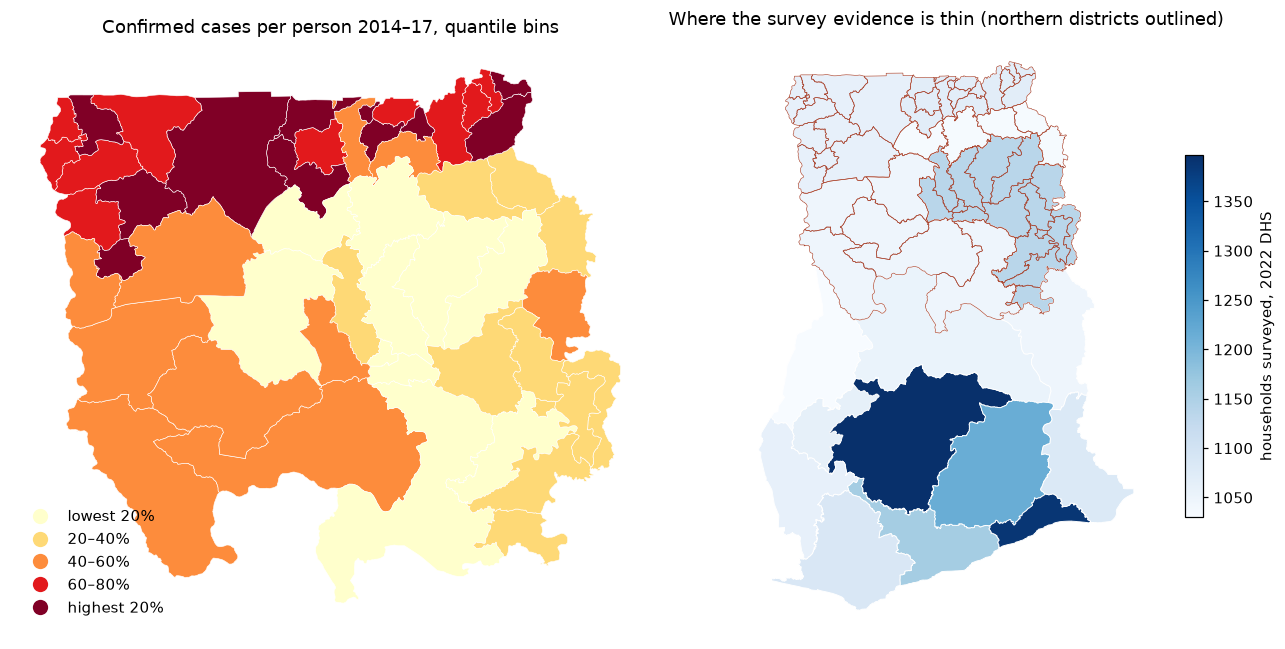

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
# Left map: districts coloured by rate. qcut makes QUANTILE bins: five groups holding the same number of districts each.
geo.assign(bin=pd.qcut(geo.rate, 5, labels=["lowest 20%", "20–40%", "40–60%", "60–80%", "highest 20%"])).plot(
    column="bin", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=.4, ax=ax[0], legend_kwds={"loc": "lower left", "frameon": False})
ax[0].set_title("Confirmed cases per person 2014–17, quantile bins")   # title and axis labels, so the chart can be read without the surrounding text
# Right map: regions coloured by how many households the survey reached there.
region_geo.plot(column="survey households", cmap="Blues", legend=True, edgecolor="white", linewidth=.6, ax=ax[1],
                legend_kwds={"label": "households surveyed, 2022 DHS", "shrink": .6})
geo.boundary.plot(ax=ax[1], color="#A8412B", linewidth=.4)             # outline our 50 districts on top, to show where they sit
ax[1].set_title("Where the survey evidence is thin (northern districts outlined)")   # title and axis labels, so the chart can be read without the surrounding text
for a in ax:   # do the same to every panel of the figure
    a.set_axis_off()                                                   # longitude/latitude tick marks add nothing here
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "05_rate_and_survey_coverage")   # write the figure to outputs/figures so the slides can use it

**Probability heatmap and data availability.** Left: the probability that a child aged 6–59 months tests positive by RDT, by region, from the 2022 DHS: the national "probability heatmap" and the only prevalence measure that covers the whole country. Right: every one of Ghana's 260 districts, shaded by whether *any* district-level case data exists for it.

districts with district-level case data: 55 of 260 (79% have none)


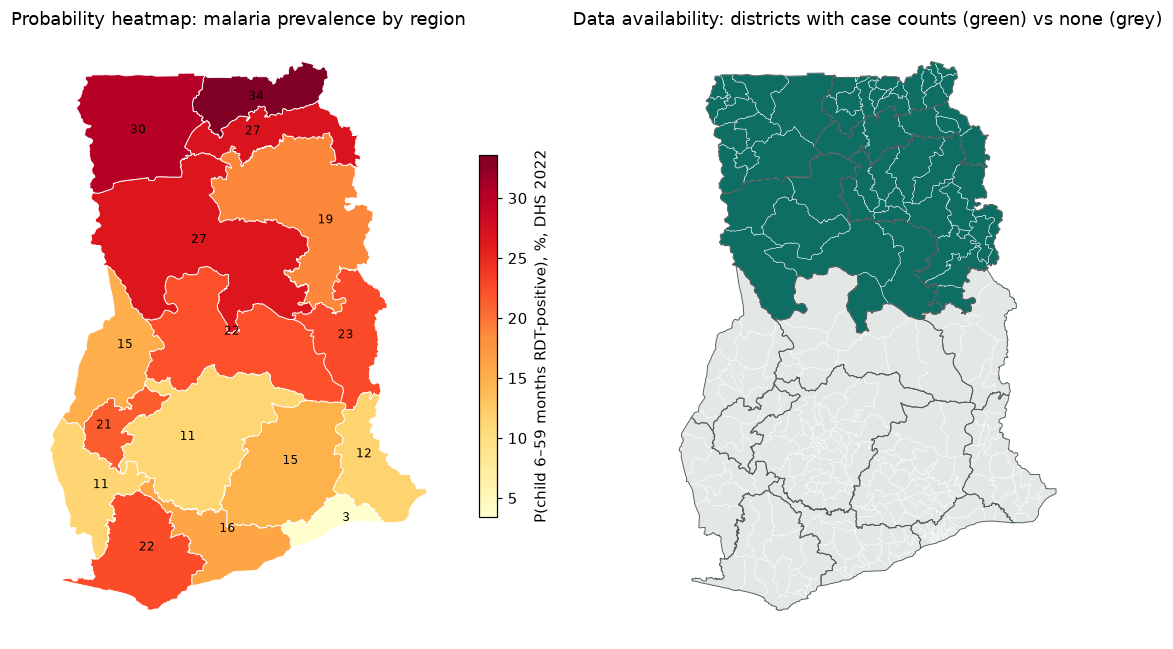

In [29]:
avail = adm2.assign(has_data=adm2.adm2_name.isin(lookup.adm2_name))   # for all 260 districts: True if we have case data for it
print(f"districts with district-level case data: {int(avail.has_data.sum())} of {len(avail)} "   # how much of the country has any district-level case data at all
      f"({100 * (1 - avail.has_data.mean()):.0f}% have none)")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
# Left: the "probability heatmap": each region coloured by the probability that a child tests positive (continuous colour scale).
region_geo.plot(column="RDT prevalence 2022 %", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=.6, ax=ax[0],
                legend_kwds={"label": "P(child 6–59 months RDT-positive), %, DHS 2022", "shrink": .6})
for _, r_ in region_geo.iterrows():                                    # write the number on each region
    p_ = r_.geometry.representative_point()                            # a point guaranteed to lie inside the polygon (a centroid can fall outside odd shapes)
    ax[0].annotate(f"{r_['RDT prevalence 2022 %']:.0f}", (p_.x, p_.y), ha="center", fontsize=8)   # write the prevalence number at that point, centred
ax[0].set_title("Probability heatmap: malaria prevalence by region")   # title and axis labels, so the chart can be read without the surrounding text
# Right: data availability. Green = district-level counts exist, grey = none.
avail.plot(color=avail.has_data.map({True: "#0F6E63", False: "#E3E7E5"}), edgecolor="white", linewidth=.3, ax=ax[1])
adm1.boundary.plot(ax=ax[1], color="#4F5A5B", linewidth=.6)            # region borders on top for orientation
ax[1].set_title("Data availability: districts with case counts (green) vs none (grey)")   # title and axis labels, so the chart can be read without the surrounding text
for a in ax:   # do the same to every panel of the figure
    a.set_axis_off()   # hide the latitude/longitude axes; they add nothing on a map
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "06_prevalence_heatmap_and_availability")   # write the figure to outputs/figures so the slides can use it

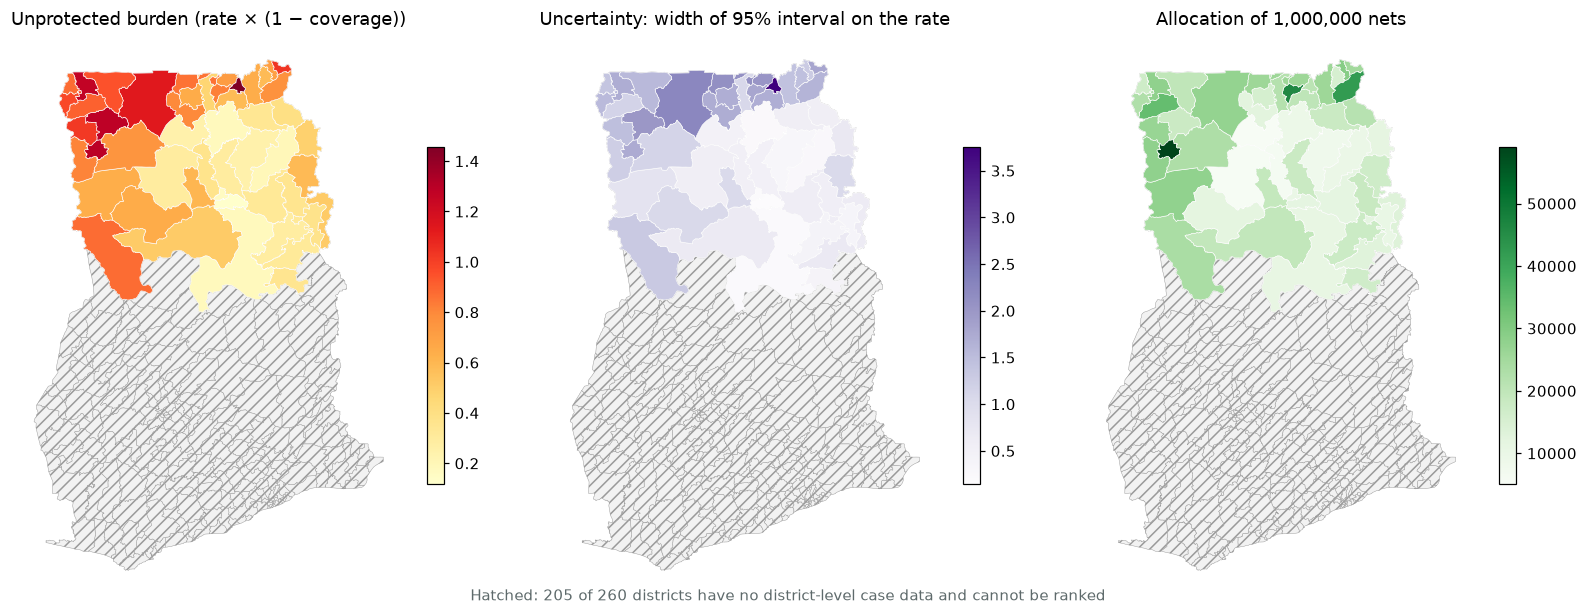

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5.5))                        # the three maps that carry the presentation, drawn on the whole country
for a, col, title, cmap in [(ax[0], "unprotected rate", "Unprotected burden (rate × (1 − coverage))", "YlOrRd"),   # where need is highest
                            (ax[1], "boot width", "Uncertainty: width of 95% interval on the rate", "Purples"),     # where we are least sure
                            (ax[2], "nets", f"Allocation of {N_NETS:,} nets", "Greens")]:                           # where the nets go
    adm2.plot(ax=a, facecolor="#F2F2F2", edgecolor="#9A9A9A", linewidth=.3, hatch="///")   # the other 205 districts: hatched grey = no district-level data, drawn underneath
    geo.plot(column=col, cmap=cmap, legend=True, edgecolor="white", linewidth=.4, ax=a, legend_kwds={"shrink": .6})   # same drawing code, different column and colours
    a.set_title(title)   # title and axis labels, so the chart can be read without the surrounding text
    a.set_axis_off()   # hide the latitude/longitude axes; they add nothing on a map
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
fig.text(0.5, 0.02, "Hatched: 205 of 260 districts have no district-level case data and cannot be ranked", ha="center", fontsize=10, color="#5E6A6B")   # one caption for all three panels
save(fig, "07_burden_uncertainty_allocation")   # write the figure to outputs/figures so the slides can use it

**Reading the three maps together.** The burden map says where cases per unprotected person are highest. The uncertainty map says where that number is least trustworthy; wide intervals come from erratic monthly reporting, which is itself a signal of a weak health system. The allocation map is the first map scaled by population and the coverage gap. A district that is dark on both the first and the second map is exactly the case the "rank on the upper bound" rule exists for. The hatched area is the rest of Ghana: 205 districts with no district-level case data, including three regions whose measured prevalence is above 22%. The recommendation can only rank what it can see.

## 13. How much should we trust the data? (LO7)

**The headline figure.** The WHO *World Malaria Report 2024* estimates **263 million cases and 597,000 deaths** worldwide in 2023. Those are not counts. Nobody counted 263 million cases. They are outputs of a statistical model that combines routine surveillance, household surveys like the DHS, and assumptions about how many sick people never reach a facility. WHO publishes them with uncertainty intervals for that reason. The Ghana series from the WHO Global Health Observatory, in `data/raw/malaria_indicators_gha.csv`, lets us see how wide that uncertainty is for the country we are working on.

      Numeric     Low    High  interval as % of estimate
year                                                    
2014  313.800 250.800 387.800                     43.600
2017  226.200 173.200 290.200                     51.700
2022  210.800 158.500 275.300                     55.400
2023  194.900 144.200 257.300                     58.000

code  MALARIA_CONF_CASES  MALARIA_SUSPECTS  MALARIA_TOTAL_CASES  confirmed_share_of_suspected
year                                                                                         
2017               7.000            19.070               13.470                         0.370
2018               4.930            15.540               11.150                         0.320
2019               6.120            11.980                6.700                         0.510
2020               5.450            10.430                5.880                         0.520


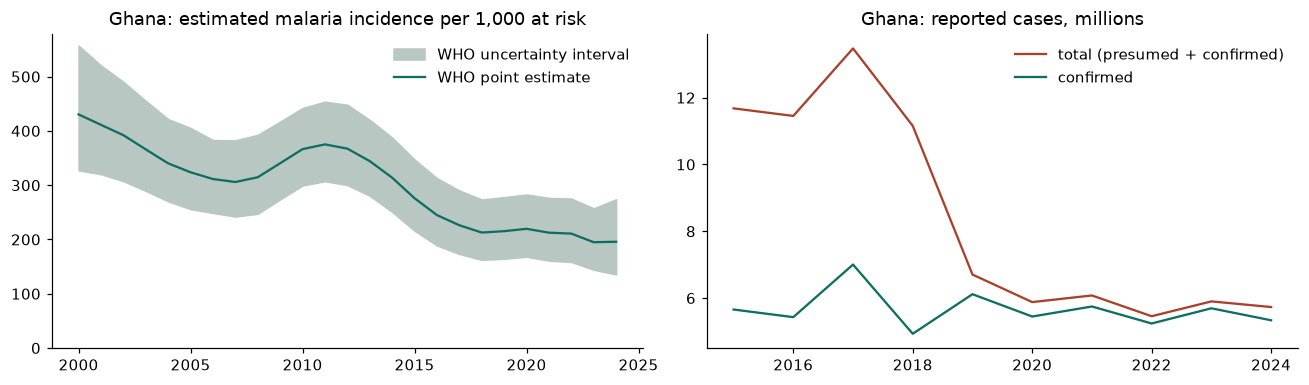

In [31]:
# WHO Global Health Observatory series for Ghana. Rename the two awkward column names we use.
who = pd.read_csv(DATA / "raw/malaria_indicators_gha.csv").rename(columns={"GHO (CODE)": "code", "YEAR (DISPLAY)": "year"})
# Estimated incidence per 1,000 at risk: WHO's point estimate (Numeric) with its own Low/High uncertainty bounds, by year.
inc = who[who.code == "MALARIA_EST_INCIDENCE"].set_index("year")[["Numeric", "Low", "High"]].sort_index()
inc["interval as % of estimate"] = 100 * (inc.High - inc.Low) / inc.Numeric   # how wide the interval is relative to the estimate
# Reported counts, reshaped so each indicator becomes a column and each year a row.
counts = who[who.code.isin(["MALARIA_CONF_CASES", "MALARIA_TOTAL_CASES", "MALARIA_SUSPECTS"])].pivot_table(index="year", columns="code", values="Numeric")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))   # create the figure (fig) and its drawing area(s) (ax); figsize = width x height in inches
ax[0].fill_between(inc.index, inc.Low, inc.High, color="#B9C7C3", label="WHO uncertainty interval")   # shaded band = the uncertainty
ax[0].plot(inc.index, inc.Numeric, color="#0F6E63", label="WHO point estimate")                        # line = the headline number
ax[0].set(title="Ghana: estimated malaria incidence per 1,000 at risk", ylim=(0, None))                # y-axis from zero so the band's size is honest
ax[0].legend(frameon=False)   # draw the legend (the key to colours and line styles), without a box around it
(counts[["MALARIA_TOTAL_CASES", "MALARIA_CONF_CASES"]] / 1e6).plot(ax=ax[1], color=["#A8412B", "#0F6E63"])   # reported cases, in millions
ax[1].set(title="Ghana: reported cases, millions", xlabel="")   # title and axis labels, so the chart can be read without the surrounding text
ax[1].legend(["total (presumed + confirmed)", "confirmed"], frameon=False)   # draw the legend (the key to colours and line styles), without a box around it
plt.tight_layout()   # adjust spacing so titles and labels do not overlap
save(fig, "08_who_uncertainty")   # write the figure to outputs/figures so the slides can use it
print(inc.loc[[2014, 2017, 2022, 2023]].round(1).to_string())         # a few years of the estimate and its interval
print()   # blank line between the two printed tables
# Reported counts around the 2019 definition change, plus confirmed cases as a share of suspected cases.
print((counts.loc[2017:2020] / 1e6).round(2).assign(confirmed_share_of_suspected=(counts.MALARIA_CONF_CASES / counts.MALARIA_SUSPECTS).round(2)).to_string())

**Critique, grounded in the numbers above.**

- **The interval is wide.** For Ghana the uncertainty interval spans roughly 45–60% of the point estimate in every year. A figure quoted as "195 per 1,000" could as honestly be 144 or 257. The global 263 million inherits that kind of uncertainty from every endemic country; it should be read as "a quarter of a billion, give or take tens of millions", never to three significant figures.
- **Reported counts depend on definitions, not only on disease.** Ghana's *total* reported cases fall from 11.2 million in 2018 to 6.7 million in 2019 while *confirmed* cases rise. Malaria did not halve in a year; presumed (untested) cases stopped being counted as testing became universal. Any trend that crosses that boundary is partly an artefact.
- **Surveillance sees only people who reach a facility.** Confirmed cases are between a third and a half of suspected cases, and people who never present are in neither number. The undercount is largest where facilities are furthest apart, the same remote districts our equity section worries about. That is why WHO models the estimate instead of adding up reports, and why modelled estimates exceed reported cases.
- **Deaths are less certain than cases.** Most malaria deaths in high-burden countries occur outside hospitals without a certified cause; 597,000 is derived from case estimates and assumed fatality rates, so its error compounds.

**So how much should we trust it?** Enough to say malaria is a very large problem concentrated in sub-Saharan Africa, and that Ghana's estimated incidence has fallen by more than a third since 2014. Not enough to rank districts, which is why this notebook builds its ranking from district-level data and carries an interval on every number.

**And our own data?** Described in `data/data_dictionary.md`, which serves as this project's **datasheet** in the sense of Gebru et al. (2021): it records provenance, collection method, licensing and known caveats for every file. The caveats that matter most here: district counts cover only 3 regions and 2014–17; net coverage is regional and from 2022; `positive_per_100k` is a four-year cumulative figure, not a prevalence; the survey extract is de-identified to region, so no district-level survey estimate is possible.

## 14. Limitations, sources, declarations

**What this analysis cannot claim.**
- District counts are 2014–17; the survey is 2022; net coverage is region-level. The allocation combines evidence from different years and resolutions and says so. In use, a planner would replace these with current figures.
- Routine surveillance counts *confirmed* cases at facilities. It undercounts where people do not reach facilities, which is where evidence is thinnest (§13).
- 13 regions have no district counts. The rule protects thin-evidence districts in principle; the ranked table can only rank the 50 districts we have.
- The objective is burden, not net *effectiveness*. A different objective (cases prevented per net) would give a different list.
- The total of 1,000,000 nets is our assumption. The ranking does not depend on it; the per-district counts scale with it.

**Sources for every statistic in this notebook.**

| Statistic | File | Original source |
|---|---|---|
| District case counts, population, rates (§2, §3, §6, §10, §11) | `ghana_district_cases.csv`, `raw/northern-ghana-districts-routine-data-2014-17.xlsx` | Ghana Health Service routine monthly surveillance, 2014–17 |
| Net ownership, weights, clusters, all bootstraps, supervised model (§4, §7–§9) | `ghana_mis_sample.csv` | Ghana 2022 DHS household recode, de-identified extract, licensed |
| Official net ownership and RDT prevalence by region (§4, §5, §12) | `ghana_region_malaria.csv` | DHS Program subnational indicators (STATcompiler/API) |
| Net coverage used in the allocation (§11) | `ghana_district_cases.csv` | Ghana 2022 DHS, weighted `has_net`, region level |
| Boundaries (§12) | `ghana_boundaries/gha_admin1/2.geojson` | HDX / COD administrative boundaries, 2021 |
| Ghana incidence and reported cases (§13) | `raw/malaria_indicators_gha.csv` | WHO Global Health Observatory |
| 263 million cases, 597,000 deaths (§13) | cited | WHO, *World Malaria Report 2024* |
| Datasheet | `data/data_dictionary.md` | Course data package; format after Gebru et al., *Datasheets for Datasets*, CACM 2021 |

**Submission checklist.**
- No cell fits, encodes or scales on pooled train+test data, except the labelled "leaky" rows of the audit in §9.
- §9 names each leak risk with a before/after number.
- Every statistic cites a source (table above); the datasheet is referenced (§13).
- AI-use declaration: in each member's individual reflection, submitted separately.
- Runs top to bottom from a fresh clone: `README.md` has the four commands.

**Data rules.** `data/` is git-ignored and never committed. This notebook and everything in `outputs/` contain aggregates only: no household rows.

**AI-use declaration (repository level).** An AI coding assistant (Claude, via Claude Code, run locally on a team member's laptop) was used extensively on this repository. It drafted the work plan, wrote the code and the explanatory text of this notebook, produced the figures, and explained the underlying statistical concepts. It worked from outputs of code executed on the laptop: aggregates, fits and intervals. During its first inspection of the files it displayed the column headers and the first two rows of the de-identified survey extract; no data file was uploaded or committed. Each team member's own use of AI, and what they personally reviewed, verified and can defend, is declared in their individual reflection.

## 15. The experiment matrix: every lever, what it does, and why we chose our route

Sections 2–12 walk one route through the analysis. At every step there was a choice, a **lever**, and we pulled it one way. This section pulls every lever every way, in a loop, so that the route is a conclusion and not a habit.

There are four families of lever, because there are four different questions:

| Block | Question | Levers | Judged by |
|---|---|---|---|
| **A** | Which distribution describes the counts? | family × offset × covariates | AIC, and what happens to α |
| **B** | How do we put an interval on a survey estimate? | method × number of resamples | width, and how stable the width is |
| **C** | How do we build and score a predictive model without fooling ourselves? | split × preprocessing scope × encoding × features × model | cross-validated AUC **on train only** |
| **D** | Which districts get nets? | estimator × imputation × coverage × ranking statistic | how much the top 10 moves |

**The discipline (and the trap).** Comparing many configurations is itself a leakage vector: score 64 configurations on the test set, pick the winner, and the winner's test score is optimistic because you selected on it. So every comparison in block C uses cross-validation *inside the training data*. The test set is scored exactly once, at the end, for the single configuration chosen by those rules.

### Block A. Distribution levers: family × offset × covariates

Three levers, twelve fits. **Family**: Poisson (variance = mean) or Negative Binomial (variance = μ + αμ²). **Offset**: model raw counts, or counts with log(population) as an offset so the model describes a rate. **Covariates**: none, region, or region + IRS. For each fit we record the AIC (lower is better) and, for the NB, α.

In [32]:
import warnings                                      # some of the twelve fits emit harmless convergence chatter; we silence it inside the loop only
full = districts.copy()                              # all 50 districts: this block describes the data, it does not predict, so no train/test split is involved
cov_sets = {"none": [], "region": ["region_name"], "region + IRS": ["region_name", "irs"]}   # the three covariate options

def design_for(df, cols):
    # Build the design matrix for a covariate option: always an intercept, then dummies for region and/or the IRS share.
    X = pd.DataFrame({"const": np.ones(len(df))}, index=df.index)               # the intercept column of 1s
    if "region_name" in cols:                                                   # add region as 0/1 columns, dropping one region as the baseline
        X = X.join(pd.get_dummies(df["region_name"], drop_first=True).astype(float))
    if "irs" in cols:                                                           # add the share of months under indoor spraying
        X["irs"] = df["irs"].values
    return X

rows = []                                            # one result row per fit
for fam, use_offset, (cov_name, cols) in itertools.product(["Poisson", "Negative Binomial"], [False, True], cov_sets.items()):   # every combination of the three levers
    X = design_for(full, cols)                       # inputs for this covariate option
    off = np.log(full.mean_population.values) if use_offset else None          # the offset lever: log(population) or nothing
    with warnings.catch_warnings():                  # keep optimiser warnings out of the notebook output
        warnings.simplefilter("ignore")
        if fam == "Poisson":
            fit = sm.GLM(full.positive_cases, X, family=sm.families.Poisson(), offset=off).fit()       # Poisson regression
            alpha_ = np.nan                          # a Poisson has no alpha
        else:
            fit = sm.NegativeBinomial(full.positive_cases, X, offset=off).fit(disp=0, maxiter=500)     # Negative Binomial regression; alpha is estimated too
            alpha_ = fit.params.iloc[-1]             # alpha is the last fitted parameter
    rows.append({"family": fam, "offset": "log(pop)" if use_offset else "none", "covariates": cov_name,
                 "parameters": len(fit.params), "AIC": fit.aic, "alpha": alpha_})   # record the levers and the two outcomes
grid_A = pd.DataFrame(rows)                          # the twelve fits as a table
grid_A.round(3).to_csv(TAB / "matrix_A_distributions.csv", index=False)       # save for the record
grid_A.pivot_table(index=["family", "offset"], columns="covariates", values=["AIC", "alpha"])[[("AIC", "none"), ("AIC", "region"), ("AIC", "region + IRS"), ("alpha", "none"), ("alpha", "region"), ("alpha", "region + IRS")]].round(3)   # levers as rows/columns, outcomes as cells

AIC                             alpha                    
covariates                          none        region  region + IRS  none region region + IRS
family            offset                                                                      
Negative Binomial log(pop)     1,309.358     1,253.832     1,252.595 0.417  0.139        0.130
                  none         1,298.201     1,256.265     1,256.838 0.342  0.145        0.141
Poisson           log(pop) 4,419,517.333 1,060,790.319 1,046,719.358   NaN    NaN          NaN
                  none     3,387,464.268 1,377,017.681 1,319,329.538   NaN    NaN          NaN

**What each lever does (block A).**

- **Family is the only lever that matters for fit.** Every Poisson row has an AIC in the millions; every NB row is near 1,300. No choice of offset or covariates rescues the Poisson. This is why the route starts with "Negative Binomial" and never looks back.
- **Covariates explain α.** Adding region cuts α from 0.417 to 0.139. Two thirds of what looked like "extra randomness" was really a difference *between regions*. α measures **unexplained** heterogeneity: give the model a reason for the spread and α shrinks. IRS then adds almost nothing (α 0.139 → 0.130, AIC better by 1.2, less than the 2-point cost of the extra parameter), so it does not earn its place on fit alone.
- **The offset is not justified by AIC, and we should say so.** With no covariates the model *without* the offset fits slightly better (1,298 against 1,309): large districts do not have proportionally more cases, so population alone is a weak explanation of the counts. Once region is included the offset version is the better one (1,254 against 1,256). We keep the offset for a different reason: the decision is about cases **per person**. A count model without an offset describes how many cases a district has, which is mostly a statement about how many people live there.

**Route:** Negative Binomial with a log-population offset; intercept-only for the distribution lesson (§3), region + IRS for the regression (§10), with IRS reported as contributing little.

### Block B. Uncertainty levers: interval method × number of resamples

Section 4 compared four interval methods once, with B = 2,000 resamples. Two levers remain unexplored. **How many resamples?** Too few and the interval itself is noisy: run it again and the width changes. **Which method?** For each method and each B we repeat the whole procedure 20 times with different random seeds and report the average width and how much the width wobbles between repeats.

In [33]:
def width_once(df, method, B, rng):
    # Width of one 95% interval on net ownership for the households in df, by one method, with B resamples.
    if method == "households (simple)":
        hh = df.has_net.values                                       # 0/1 outcomes
        est = hh[rng.integers(0, len(hh), (B, len(hh)))].mean(1)      # resample households with replacement, B times
    else:
        c = df.groupby("cluster").agg(s=("has_net", "sum"), n=("has_net", "size"),                    # per-cluster net owners and household counts
                                      ws=("sample_weight", lambda w: (w * df.loc[w.index, "has_net"]).sum()),   # per-cluster weighted net owners
                                      w=("sample_weight", "sum"))                                     # per-cluster total weight
        idx = rng.integers(0, len(c), (B, len(c)))                   # resample whole clusters with replacement, B times
        est = (c.ws.values[idx].sum(1) / c.w.values[idx].sum(1)) if method == "clusters, weighted" else (c.s.values[idx].sum(1) / c.n.values[idx].sum(1))   # weighted or unweighted estimate per resample
    lo, hi = np.percentile(est, [2.5, 97.5])                          # middle 95% of the resampled estimates
    return hi - lo                                                    # the interval's width

rows = []                                            # one row per (method, B)
for method, B in itertools.product(["households (simple)", "clusters", "clusters, weighted"], [100, 500, 2000, 5000]):   # both levers, every combination
    widths = [width_once(northern, method, B, np.random.default_rng(seed)) for seed in range(20)]   # 20 independent repeats, each with its own seed
    rows.append({"method": method, "B": B, "mean width": np.mean(widths), "sd of width across repeats": np.std(widths)})   # average width and its run-to-run wobble
grid_B = pd.DataFrame(rows)                          # twelve combinations as a table
grid_B.round(4).to_csv(TAB / "matrix_B_uncertainty.csv", index=False)         # save for the record
grid_B.pivot_table(index="method", columns="B", values=["mean width", "sd of width across repeats"]).round(4)   # methods as rows, B as columns

mean width                   sd of width across repeats                  
B                         100   500   2000  5000                       100   500   2000  5000
method                                                                                       
clusters                 0.123 0.125 0.125 0.125                      0.013 0.005 0.003 0.002
clusters, weighted       0.119 0.121 0.122 0.122                      0.012 0.005 0.003 0.002
households (simple)      0.053 0.054 0.054 0.055                      0.005 0.002 0.001 0.001

**What each lever does (block B).**

- **Method decides the width.** Resampling households gives about 0.054; resampling clusters gives about 0.12, at every B. No number of resamples turns the wrong method into the right one: more resamples only estimate the *wrong* interval more precisely.
- **B decides how repeatable the width is, not how wide it is.** At B = 100 the width wobbles by ±0.013 from run to run, a tenth of itself. By B = 2,000 the wobble is ±0.003 and B = 5,000 barely improves on it. So 2,000 is enough, and more is wasted computing.
- **Weights barely change the width** (0.125 → 0.122). Their job is to move the *centre* of the interval to the right place (§4: 66.1% unweighted, 67.7% weighted, 67.6% official).

**Route:** weighted cluster bootstrap, B = 2,000.

### Block C. Model levers: split × preprocessing scope × encoding × features × model

The supervised task from section 8: predict whether a household owns a net. Five levers, 64 configurations, every one scored by 5-fold cross-validation on the **training** households.

| Lever | Options | Which options leak |
|---|---|---|
| CV split | GroupKFold by cluster · random KFold | random (households from one cluster on both sides of a fold) |
| Preprocessing scope | fitted inside each training fold · fitted once on **all** survey rows | pooled |
| Region encoding | one-hot · region code as a number · target-encode region on all rows · target-encode cluster on all rows | both target encodings. *Region as a number* does not leak; it is simply wrong (it claims region 12 is "twice" region 6) |
| Features | planner-knowable only · plus `children_under_net_last_night` | the post-treatment feature |
| Model | logistic regression · gradient-boosted trees | neither |

A configuration is **clean** only if every lever is at its non-leaking option. The point of the block: see whether the *best-scoring* configurations are the clean ones.

In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier          # a second, more flexible model, so "model" is a lever too

region_te = survey.groupby("region").has_net.mean()                  # LEAKY on purpose: average outcome per region, computed over ALL rows (train and test)
cluster_te = survey.groupby("cluster").has_net.mean()                # LEAKY on purpose: average outcome per cluster, over ALL rows
def with_encodings(df):
    # Add the alternative encodings of "where the household is" as extra columns; each configuration picks one of them.
    return df.assign(region_num=df.region.astype(float),             # region code treated as a plain number
                     region_te=df.region.map(region_te),             # naive target encoding of region
                     cluster_te=df.cluster.map(cluster_te))          # naive target encoding of cluster
train_X, all_X = with_encodings(svy_train), with_encodings(survey)  # training rows (what CV runs on) and ALL rows (what the pooled-scope leak fits on)

ENCODINGS = {"one-hot region": (["region", "residence"], []),                       # (columns to one-hot, extra numeric columns)
             "region as a number": (["residence"], ["region_num"]),
             "target-encode region (all rows)": (["residence"], ["region_te"]),
             "target-encode cluster (all rows)": (["residence"], ["cluster_te"])}
MODELS = {"logistic": lambda: LogisticRegression(max_iter=1000),                     # functions, so every configuration gets a fresh unfitted model
          "boosted trees": lambda: HistGradientBoostingClassifier(max_iter=60, random_state=0)}
CLEAN = {"cv": "GroupKFold", "scope": "train-only", "encoding": "one-hot region", "features": "clean", "model": "logistic"}   # the route taken in section 8

rows = []                                            # one row per configuration
for cv_name, scope, enc, feats, model_name in itertools.product(["GroupKFold", "random KFold"], ["train-only", "pooled"], ENCODINGS, ["clean", "+ post-treatment"], MODELS):   # all 64 combinations
    cat_cols, extra_num = ENCODINGS[enc]                                              # which columns this encoding uses
    num_cols = NUMERIC + extra_num + (["children_under_net_last_night"] if feats == "+ post-treatment" else [])   # numeric columns, plus the leaky feature if this lever is on
    pre = ColumnTransformer([("num", StandardScaler(), num_cols),                     # scale the numeric columns
                             ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])   # one-hot the categorical ones (dense output, which the tree model needs)
    splitter = GroupKFold(5) if cv_name == "GroupKFold" else KFold(5, shuffle=True, random_state=0)   # the split lever
    if scope == "train-only":                                                         # CLEAN: the preprocessor sits inside the pipeline, so each fold refits it on that fold's training part only
        est, X_cv = Pipeline([("pre", pre), ("model", MODELS[model_name]())]), train_X[num_cols + cat_cols]
    else:                                                                             # LEAKY: fit the preprocessor once on ALL survey rows, then cross-validate only the model
        pre.fit(all_X[num_cols + cat_cols])
        est, X_cv = MODELS[model_name](), pre.transform(train_X[num_cols + cat_cols])
    groups = svy_train.cluster if cv_name == "GroupKFold" else None                   # only the grouped splitter uses cluster ids; random KFold must not be given them
    auc = cross_val_score(est, X_cv, svy_train[TARGET], groups=groups, cv=splitter, scoring="roc_auc").mean()   # mean AUC over the five folds
    cfg = {"cv": cv_name, "scope": scope, "encoding": enc, "features": feats, "model": model_name}   # this configuration's lever settings
    leaks = [k for k in ["cv", "scope", "encoding", "features"] if cfg[k] != CLEAN[k] and cfg[k] != "region as a number"]   # which levers are at a leaking option ("region as a number" is wrong, not leaky)
    rows.append({**cfg, "CV AUC": auc, "leaks": ", ".join(leaks) or "none"})          # record settings, score and the leaks present
grid_C = pd.DataFrame(rows).sort_values("CV AUC", ascending=False).reset_index(drop=True)   # best score first
grid_C.round(4).to_csv(TAB / "matrix_C_models.csv", index=False)                       # save all 64 for the record
print(f"configurations: {len(grid_C)};  clean: {(grid_C.leaks == 'none').sum()};  of the 10 best-scoring, clean: {(grid_C.head(10).leaks == 'none').sum()}")   # the headline
grid_C.head(8).round(3)                              # the eight best-scoring configurations

configurations: 64;  clean: 4;  of the 10 best-scoring, clean: 0


,cv,scope,encoding,features,model,CV AUC,leaks
0,random KFold,pooled,target-encode cluster (all rows),+ post-treatment,logistic,0.804,"cv, scope, encoding, features"
1,random KFold,train-only,target-encode cluster (all rows),+ post-treatment,logistic,0.804,"cv, encoding, features"
2,GroupKFold,pooled,target-encode cluster (all rows),+ post-treatment,logistic,0.803,"scope, encoding, features"
3,GroupKFold,train-only,target-encode cluster (all rows),+ post-treatment,logistic,0.803,"encoding, features"
4,GroupKFold,pooled,target-encode cluster (all rows),+ post-treatment,boosted trees,0.801,"scope, encoding, features"
5,GroupKFold,train-only,target-encode cluster (all rows),+ post-treatment,boosted trees,0.801,"encoding, features"
6,random KFold,pooled,target-encode cluster (all rows),+ post-treatment,boosted trees,0.795,"cv, scope, encoding, features"
7,random KFold,train-only,target-encode cluster (all rows),+ post-treatment,boosted trees,0.795,"cv, encoding, features"


clean configurations, by CV AUC on train:
          encoding         model  CV AUC
    one-hot region      logistic   0.676
    one-hot region boosted trees   0.672
region as a number boosted trees   0.671
region as a number      logistic   0.645

chosen by the rules (best clean CV): one-hot region + logistic


CV AUC  change vs clean route      this option is
lever    option                                                                             
cv       random KFold                       0.678                  0.002                LEAK
         GroupKFold                         0.676                  0.000           our route
scope    pooled                             0.676                  0.000                LEAK
         train-only                         0.676                  0.000           our route
encoding target-encode cluster (all rows)   0.740                  0.064                LEAK
         one-hot region                     0.676                  0.000           our route
         target-encode region (all rows)    0.673                 -0.003                LEAK
         region as a number                 0.645                 -0.031  honest alternative
features + post-treatment                   0.758                  0.082                LEAK
         clean                              0.676                  0.000           our route
model    logistic                           0.676                  0.000           our route
         boosted trees                      0.672                 -0.004  honest alternative

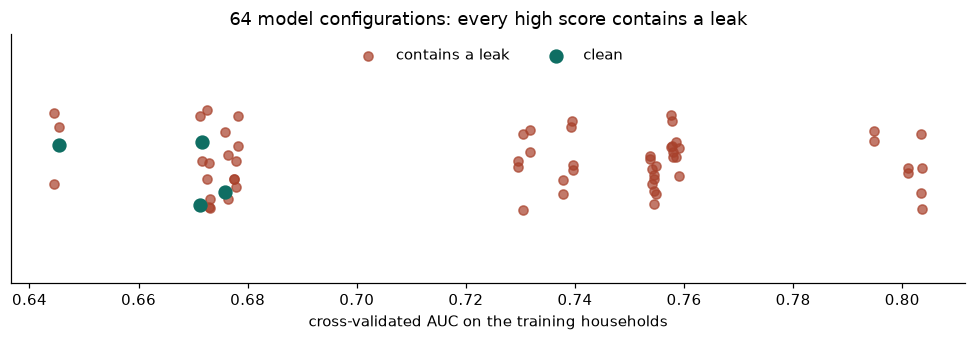

In [35]:
# One lever at a time: start from the clean route, change ONE lever, and see how far the score moves.
base = grid_C[(grid_C[list(CLEAN)] == pd.Series(CLEAN)).all(axis=1)]["CV AUC"].iloc[0]   # the clean route's own CV score
rows = []                                            # one row per (lever, option)
for lever in CLEAN:                                  # each of the five levers in turn
    for option in grid_C[lever].unique():            # each option that lever can take
        target = {**CLEAN, lever: option}            # the clean route with just this one lever changed
        score = grid_C[(grid_C[list(target)] == pd.Series(target)).all(axis=1)]["CV AUC"].iloc[0]   # look up that configuration's score
        rows.append({"lever": lever, "option": option, "CV AUC": score, "change vs clean route": score - base,
                     "this option is": "our route" if option == CLEAN[lever] else ("LEAK" if lever != "model" and option != "region as a number" else "honest alternative")})   # label the option
lever_C = pd.DataFrame(rows).set_index(["lever", "option"])   # the lever table
lever_C.round(4).to_csv(TAB / "matrix_C_levers.csv")          # save for the record

clean_rows = grid_C[grid_C.leaks == "none"]          # the configurations we are ALLOWED to choose between
best_clean = clean_rows.iloc[0]                      # the best of them, by CV on train
print("clean configurations, by CV AUC on train:")
print(clean_rows[["encoding", "model", "CV AUC"]].round(4).to_string(index=False))   # every clean option and its score
print(f"\nchosen by the rules (best clean CV): {best_clean.encoding} + {best_clean.model}")   # the winner under the discipline

fig, ax = plt.subplots(figsize=(9, 3.2))             # one strip of dots: every configuration's score
is_clean = grid_C.leaks == "none"                    # True for clean configurations
ax.scatter(grid_C.loc[~is_clean, "CV AUC"], np.zeros((~is_clean).sum()) + RNG.uniform(-.25, .25, (~is_clean).sum()), color="#A8412B", alpha=.7, label="contains a leak")   # leaky configs, jittered vertically so dots do not overlap
ax.scatter(grid_C.loc[is_clean, "CV AUC"], np.zeros(is_clean.sum()) + RNG.uniform(-.25, .25, is_clean.sum()), color="#0F6E63", s=70, label="clean")                          # clean configs, larger
ax.set_yticks([])                                    # the vertical position is only jitter, so no y-axis
ax.set_ylim(-.6, .6)                                 # a little room around the dots
ax.set(title="64 model configurations: every high score contains a leak", xlabel="cross-validated AUC on the training households")   # title and axis label
ax.legend(frameon=False, loc="upper center", ncol=2) # legend along the top
plt.tight_layout()                                   # tidy spacing
save(fig, "09_matrix_models")                        # save for the slides
lever_C.round(3)                                     # display the lever table

In [36]:
# The ONE touch of the test set for this block: score the configuration chosen by CV among the clean options.
cat_cols, extra_num = ENCODINGS[best_clean.encoding]                                   # columns for the chosen encoding
chosen = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), NUMERIC + extra_num),                              # preprocessing, to be fitted on train only
                                               ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])),
                   ("model", MODELS[best_clean.model]())])                             # the chosen model, unfitted
test_X = with_encodings(svy_test)                                                      # test rows with the same helper columns
chosen.fit(train_X[NUMERIC + extra_num + cat_cols], svy_train[TARGET])                 # fit everything on TRAIN
final_auc = roc_auc_score(svy_test[TARGET], chosen.predict_proba(test_X[NUMERIC + extra_num + cat_cols])[:, 1])   # score once on TEST
print(f"chosen route: {best_clean.encoding} + {best_clean.model}")                     # what was chosen
print(f"CV AUC on train {best_clean['CV AUC']:.3f}  ->  test AUC {final_auc:.3f}  (gap {final_auc - best_clean['CV AUC']:+.3f})")   # CV estimate versus the single honest test score

chosen route: one-hot region + logistic
CV AUC on train 0.676  ->  test AUC 0.660  (gap -0.016)


**What each lever does (block C).**

- **Of 64 configurations, 4 are clean, and none of the 10 best-scoring is clean.** In the figure every score above 0.70 is a leak. If we had "picked the winner" we would have picked AUC 0.804: a model given the answer twice over (its cluster's average outcome and a feature that only exists if the household owns a net). This is the single most important result in the block: **the score cannot tell you which configuration is trustworthy; only the design can.**
- **The two big levers are both leaks.** The post-treatment feature adds +0.082 and cluster target encoding +0.064. Neither is a better model.
- **Three leaks that barely move the score are still leaks.** Random folds +0.002, pooled preprocessing +0.000, region target encoding −0.003 (a leak that does not even help: with 16 regions and 17,933 rows a region's average is almost the same information as its one-hot column). Their harm is small *here* because there are no missing cells, the scales are stable and the features say little about which cluster a household is in. On another dataset the same habits would cost a great deal, which is why the rule is followed regardless of the measured gap.
- **Honest alternatives.** *Region as a number* loses 0.031 for logistic regression because it invents an order (region 12 is not "twice" region 6), yet boosted trees are almost unaffected (0.671), since a tree can cut the number line anywhere. *Boosted trees* instead of logistic regression changes the score by −0.004: a more flexible model buys nothing, so the limit is the information in the features, not the model.

**Route, chosen by the rule rather than by the best score:** one-hot region + logistic regression, the best of the four clean configurations by cross-validation on train (0.676). Scored once on the held-out clusters: 0.660. The small drop is the honest cost of new clusters; the CV estimate was close, which is what a clean pipeline is supposed to deliver.

### Block D. Allocation levers: estimator × imputation × coverage × ranking statistic

This is the block that decides who gets nets. Four levers, 80 configurations. For each we record the top 10 and compare it with the route taken in section 11.

| Lever | Options |
|---|---|
| **Estimator** of district burden | raw case count · raw rate (cases per person) · empirical-Bayes shrunk rate (the NB's own estimate of each district's rate) · NB regression prediction (region + IRS) · common-rate model × population (what an intercept-only Poisson or NB predicts) |
| **Imputation** of the 7 missing months | counted as zero · district median |
| **Coverage** adjustment | none · × (1 − regional net coverage) |
| **Ranking statistic** | the mean · upper 95% bound (month bootstrap) · upper 95% bound (NB parametric) · *lower* 95% bound (the anti-equity rule: "only fund what we are sure of") |

In [37]:
rng_D = np.random.default_rng(1)                     # a separate seeded generator for this block

def district_base(col):
    # Per-district cases, population, rate and month-bootstrap interval, using monthly column `col` ("positive" or "positive_imputed").
    out = []                                         # one row per district
    for name, g in monthly.groupby("district"):      # each district's 48 monthly records
        pos, pop = g[col].fillna(0).values, g.population.values            # monthly positives (any remaining gaps as zero) and monthly population
        idx = rng_D.integers(0, len(g), (1000, len(g)))                     # 1000 resamples of the months, with replacement
        r_ = pos[idx].sum(1) / pop[idx].mean(1)                             # each resample's 4-year rate
        out.append({"district": name, "cases": pos.sum(), "pop": pop.mean(), "rate": pos.sum() / pop.mean(),
                    "boot_lo": np.percentile(r_, 2.5), "boot_hi": np.percentile(r_, 97.5)})   # point estimate and interval
    return pd.DataFrame(out).merge(districts[["district", "region_name", "irs", "net_coverage_pct"]], on="district")   # attach region, IRS share and coverage

def estimates(b):
    # Every estimator of district burden, as columns. Each is a SCORE used for ranking: higher = more burden.
    m = b.cases.sum() / b["pop"].sum()               # the overall rate across all districts
    r_ = 1 / alpha_hat                               # NB "size" parameter from section 3
    X = design_for(b, ["region_name", "irs"])        # regression inputs (function from block A)
    glm = sm.GLM(b.cases, X, family=sm.families.NegativeBinomial(alpha=alpha_hat), offset=np.log(b["pop"])).fit()   # NB regression on region + IRS
    return pd.DataFrame({"raw count": b.cases,                                        # total cases: mostly measures population
                         "raw rate": b.rate,                                          # cases per person
                         "shrunk rate (empirical Bayes)": (b.cases + r_) / (b["pop"] + r_ / m),   # Gamma-Poisson posterior mean: the raw rate pulled toward the overall rate m
                         "NB regression (region + IRS)": glm.predict(X, offset=np.log(b["pop"])) / b["pop"],   # the model's predicted rate
                         "common-rate model x population": m * b["pop"]})             # what an intercept-only count model predicts: one rate for everyone

rows, tops = [], {}                                  # result rows, and each configuration's top-10 set
for imp in ["zero", "district median"]:              # the imputation lever
    b = district_base("positive" if imp == "zero" else "positive_imputed")            # rebuild rates and intervals under this treatment
    E = estimates(b)                                 # all five estimators
    nbq = stats.nbinom(1 / alpha_hat, 1 / (1 + alpha_hat * b.cases.values))            # NB distribution centred on each district's own count
    factor = {"mean": np.ones(len(b)),                                                # multiply each estimate by 1 ...
              "upper bound (month bootstrap)": (b.boot_hi / b.rate).values,           # ... or by how far the bootstrap's upper bound sits above the rate
              "upper bound (NB parametric)": nbq.ppf(0.975) / b.cases.values,         # ... or by the NB's upper bound relative to the count
              "lower bound (month bootstrap)": (b.boot_lo / b.rate).values}           # ... or by the LOWER bound: rewards certainty, the opposite of our equity rule
    for est_name, cov, stat in itertools.product(E.columns, ["none", "x (1 - coverage)"], factor):   # the other three levers
        score = E[est_name].values * factor[stat] * ((1 - b.net_coverage_pct.values / 100) if cov != "none" else 1)   # the ranking score for every district
        key = (est_name, imp, cov, stat)             # this configuration's identity
        tops[key] = set(b.district[np.argsort(-score)[:10]])                          # its ten highest-scoring districts
        rows.append({"estimator": est_name, "imputation": imp, "coverage": cov, "statistic": stat, "score": score})   # keep the scores for rank correlations

ROUTE = ("raw rate", "zero", "x (1 - coverage)", "upper bound (month bootstrap)")     # the route taken in section 11
grid_D = pd.DataFrame(rows)                          # 80 configurations
route_score = grid_D[(grid_D[["estimator", "imputation", "coverage", "statistic"]] == pd.Series(dict(zip(["estimator", "imputation", "coverage", "statistic"], ROUTE)))).all(axis=1)].score.iloc[0]   # our route's scores
grid_D["top-10 shared with our route"] = [len(tops[k] & tops[ROUTE]) for k in tops]   # overlap of each configuration's top 10 with ours
grid_D["rank correlation with our route"] = [stats.spearmanr(s, route_score)[0] for s in grid_D.score]   # Spearman: do the two configurations order ALL 50 districts similarly?
grid_D.drop(columns="score").round(3).to_csv(TAB / "matrix_D_allocation.csv", index=False)   # save all 80 for the record
print(f"configurations: {len(grid_D)};  top-10 shared with our route: min {grid_D['top-10 shared with our route'].min()}, median {grid_D['top-10 shared with our route'].median():.0f}, max 10")

configurations: 80;  top-10 shared with our route: min 0, median 4, max 10


In [38]:
# One lever at a time, from our route: change ONE lever and see how much the list moves.
LEVERS = ["estimator", "imputation", "coverage", "statistic"]    # lever names, in the order used by ROUTE
rows = []                                            # one row per (lever, option)
for li, lever in enumerate(LEVERS):                  # each lever in turn
    for option in grid_D[lever].unique():            # each option of that lever
        key = tuple(option if j == li else ROUTE[j] for j in range(4))                # our route with just this lever changed
        order = ["estimator", "imputation", "coverage", "statistic"]                  # column order matching the key
        row = grid_D[(grid_D[order] == pd.Series(dict(zip(order, key)))).all(axis=1)].iloc[0]   # look up that configuration
        rows.append({"lever": lever, "option": option, "top-10 shared with our route": row["top-10 shared with our route"],
                     "rank correlation": row["rank correlation with our route"],
                     "enters the top 10": ", ".join(sorted(tops[key] - tops[ROUTE])) or "-",   # districts this option would add
                     "leaves the top 10": ", ".join(sorted(tops[ROUTE] - tops[key])) or "-",   # districts this option would drop
                     "": "our route" if option == ROUTE[li] else ""})                 # mark the option we actually took
lever_D = pd.DataFrame(rows).set_index(["lever", "option"])   # the lever table
lever_D.round(3).to_csv(TAB / "matrix_D_levers.csv")          # save for the record
pd.set_option("display.max_colwidth", 90)            # let the district lists show in full
lever_D.round(3)                                     # display it

top-10 shared with our route  rank correlation  \
lever      option                                                                           
estimator  raw count                                                  4             0.727   
           raw rate                                                  10             1.000   
           shrunk rate (empirical Bayes)                             10             1.000   
           NB regression (region + IRS)                               7             0.798   
           common-rate model x population                             0            -0.615   
imputation zero                                                      10             1.000   
           district median                                           10             0.998   
coverage   none                                                       6             0.940   
           x (1 - coverage)                                          10             1.000   
statistic  mean                                                       9             0.997   
           upper bound (month bootstrap)                             10             1.000   
           upper bound (NB parametric)                                9             0.997   
           lower bound (month bootstrap)                              9             0.993   

                                                                                                                   enters the top 10  \
lever      option                                                                                                                      
estimator  raw count                                              Bawku, Bolgatanga, Garu-Tempane, Jirapa, Sawla-Tuna-Kalba, Wa West   
           raw rate                                                                                                                -   
           shrunk rate (empirical Bayes)                                                                                           -   
           NB regression (region + IRS)                                                                     Jirapa, Wa East, Wa West   
           common-rate model x population  Bunkpurugu-Yunyoo, East Gonja, East Mamprusi, Gushiegu, Nanumba North, Sagnarigu, Save...   
imputation zero                                                                                                                    -   
           district median                                                                                                         -   
coverage   none                                                          Bolgatanga, Builsa South, Garu-Tempane, Kasena-Nankana West   
           x (1 - coverage)                                                                                                        -   
statistic  mean                                                                                                               Jirapa   
           upper bound (month bootstrap)                                                                                           -   
           upper bound (NB parametric)                                                                                        Jirapa   
           lower bound (month bootstrap)                                                                                      Jirapa   

                                                                                                                   leaves the top 10             
lever      option                                                                                                                                
estimator  raw count                                               Daffiama-Bussie-Issa, Lawra, Nabdam, Nandom, Pusiga, Sissala West             
           raw rate                                                                                                                -  our route  
           shrunk rate

rate-based configurations: 48
robust core (top 10 in at least 80%): ['Daffiama-Bussie-Issa', 'Lambussie-Karni', 'Nabdam', 'Pusiga', 'Wa']
decided by the levers (40-80%):       ['Bolgatanga', 'Garu-Tempane', 'Jirapa', 'Lawra', 'Nadowli-Kaleo', 'Sissala East', 'Sissala West']


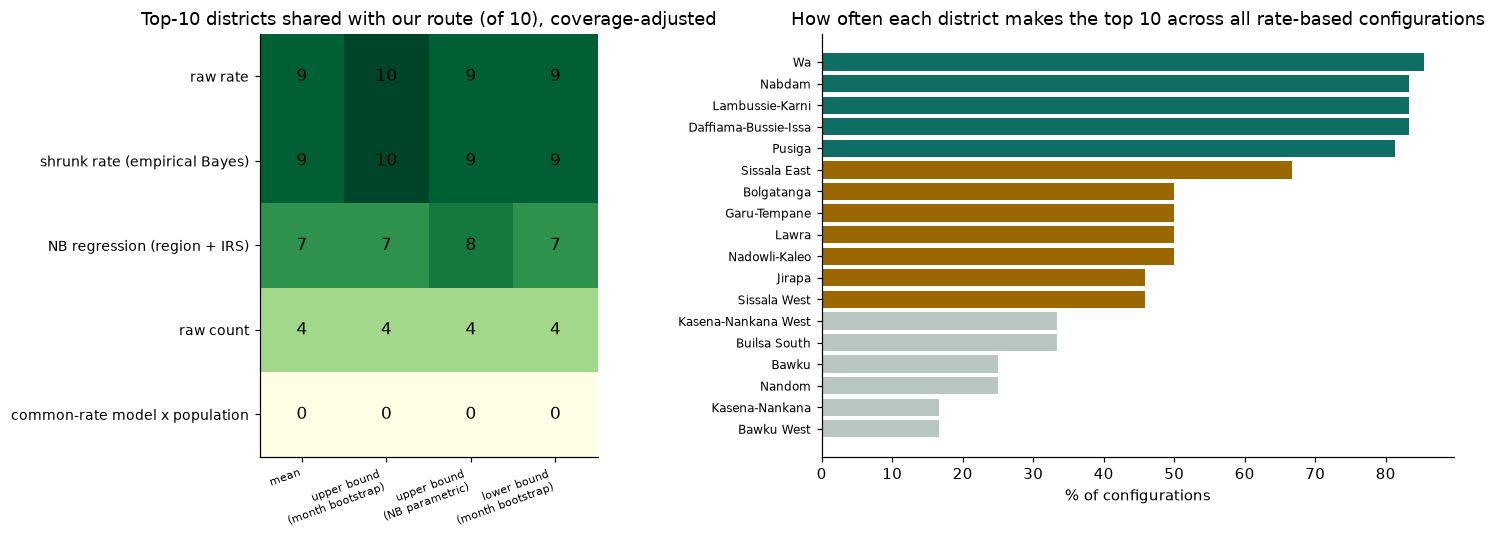

In [39]:
# Two pictures of the full grid. Left: how each estimator x statistic pair compares with our route. Right: which districts are robust.
sensible = grid_D[~grid_D.estimator.isin(["raw count", "common-rate model x population"])]   # the configurations that rank by a per-person rate
appear = pd.Series([d_ for k in tops if k[0] not in ("raw count", "common-rate model x population") for d_ in tops[k]]).value_counts() / len(sensible)   # share of rate-based configurations in which each district makes the top 10

fig, ax = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.1, 1]})    # two panels
heat = grid_D[grid_D.coverage == "x (1 - coverage)"].pivot_table(index="estimator", columns="statistic", values="top-10 shared with our route")   # mean overlap per estimator x statistic, coverage on
heat = heat.loc[["raw rate", "shrunk rate (empirical Bayes)", "NB regression (region + IRS)", "raw count", "common-rate model x population"],
                ["mean", "upper bound (month bootstrap)", "upper bound (NB parametric)", "lower bound (month bootstrap)"]]   # a readable order
im = ax[0].imshow(heat.values, cmap="YlGn", vmin=0, vmax=10)                           # the heatmap itself
for (i_, j_), v in np.ndenumerate(heat.values):                                        # write each cell's number on it
    ax[0].text(j_, i_, f"{v:.0f}", ha="center", va="center", fontsize=11)
ax[0].set_xticks(range(heat.shape[1]))                                                 # one tick per statistic
ax[0].set_xticklabels([c.replace(" (", "\n(") for c in heat.columns], fontsize=7, rotation=20, ha="right")   # statistic names, wrapped and tilted so they do not collide
ax[0].set_yticks(range(heat.shape[0]))                                                 # one tick per estimator
ax[0].set_yticklabels(heat.index, fontsize=9)                                          # estimator names
ax[0].set_title("Top-10 districts shared with our route (of 10), coverage-adjusted")   # panel title
top = appear.head(18).iloc[::-1]                                                       # the 18 most frequent districts, reversed so the top one is drawn at the top
ax[1].barh(top.index, top.values * 100, color=["#0F6E63" if v > .8 else "#9A6700" if v > .4 else "#B9C7C3" for v in top.values])   # green = robust, amber = depends on the levers, grey = rarely
ax[1].set(title="How often each district makes the top 10 across all rate-based configurations", xlabel="% of configurations")   # panel title and axis label
ax[1].tick_params(axis="y", labelsize=8)                                               # smaller district labels
plt.tight_layout()                                                                     # tidy spacing
save(fig, "10_matrix_allocation")                                                      # save for the slides
print(f"rate-based configurations: {len(sensible)}")                                   # how many configurations the percentages are out of
print("robust core (top 10 in at least 80%):", sorted(appear[appear >= .8].index))     # districts that survive almost any reasonable choice
print("decided by the levers (40-80%):      ", sorted(appear[(appear < .8) & (appear >= .4)].index))   # districts whose place depends on the choices made

**What each lever does (block D).**

- **The estimator is the biggest lever, and two of the options are traps.**
  - *Common-rate model × population* shares **0 of 10** districts with our route and ranks the 50 districts almost in reverse (rank correlation −0.62). This is what an intercept-only Poisson or NB actually predicts: one rate for everyone, so "expected cases" is just population. It would send nets to Tamale and Sagnarigu, the large districts, which have some of the *lowest* rates. A model can fit the distribution well (§3) and still be useless for ranking.
  - *Raw count* shares 4 of 10, for the same reason in milder form.
  - *NB regression (region + IRS)* shares 7 of 10. It predicts from region and IRS only, so every district with the same region and spraying history gets the same rate: it ranks regions, not districts. Nabdam, the highest-rate district in the data, drops out because the model has no way to know it is unusual.
  - *Shrunk rate (empirical Bayes)* is **identical** to the raw rate, 10 of 10. Shrinkage pulls a district toward the overall average with a weight worth about 1/α ≈ 2.4 "pseudo-cases"; against real counts of 40,000 or more that is nothing. Shrinkage matters when counts are small. Here it is a lever that does no work, and knowing that is worth as much as knowing which levers do.
- **Coverage is the second lever: 6 of 10.** Turning it off swaps four Upper West districts (Lawra, Nadowli-Kaleo, Nandom, Sissala West) for four Upper East ones (Bolgatanga, Builsa South, Garu-Tempane, Kasena-Nankana West). Coverage is one number per region (Upper East 80%, Upper West 70%), so it moves districts in regional blocks. This is the choice the panel should press on, because the coverage figure is regional and from 2022.
- **The ranking statistic is a small lever here: 9 of 10.** Mean, NB upper bound and even the *lower* bound all give the same list, differing from ours in one marginal place (Jirapa in, Nandom out). The NB parametric upper bound reorders nothing relative to the mean, and cannot: with one common α the interval is proportional to the count, so multiplying every district by the same factor leaves the order unchanged. Only an interval that differs *by district*, like the month bootstrap, can move anyone.
- **Imputation does nothing to the list: 10 of 10**, rank correlation 0.998.

**Across all 48 rate-based configurations**, five districts make the top 10 at least 80% of the time: **Wa, Nabdam, Lambussie-Karni, Daffiama-Bussie-Issa and Pusiga**. They are the robust core of the recommendation; they survive almost any reasonable choice. Sissala East follows at 67%. Then comes a band of districts at about 50%: exactly the ones the coverage lever swaps. Across all 80 configurations the median overlap with our route is only 4 of 10, but that figure is dominated by the two trap estimators; among sensible estimators the list is stable.

### Why we take the route we take

| Lever | Options tried | Size of effect | Route | Reason |
|---|---|---|---|---|
| Distribution family | Poisson, NB | decisive: AIC millions vs ~1,300 | **NB** | Poisson gives observed data probability zero |
| Offset | none, log(population) | small on AIC, either direction | **log(population)** | the decision is per person; not chosen on AIC |
| Covariates | none, region, region + IRS | α 0.42 → 0.14 with region; IRS negligible | intercept-only to describe, region + IRS to regress | region explains two thirds of the over-dispersion |
| Interval method | normal, households, clusters, weighted clusters | width 0.054 vs 0.12 | **weighted clusters** | matches how the survey was sampled; centre matches DHS |
| Resamples B | 100 … 5,000 | stability only; flat after 2,000 | **2,000** | width repeatable to ±0.003 |
| CV split | grouped, random | +0.002 | **grouped by cluster** | households in a cluster are not independent |
| Preprocessing scope | train-only, pooled | +0.000 | **train-only, in a Pipeline** | the rule costs nothing here and protects everywhere |
| Encoding | one-hot, number, target (region), target (cluster) | −0.031 … +0.064 | **one-hot** | target encoding leaks; a number invents an order |
| Features | clean, + post-treatment | +0.082 | **clean** | the feature is a consequence of the target |
| Model | logistic, boosted trees | −0.004 | **logistic** | best clean CV score; flexibility buys nothing |
| Burden estimator | count, rate, shrunk rate, NB regression, common rate × pop | 0 to 10 of 10 | **raw rate** | counts and common-rate models rank by population; regression ranks regions; shrinkage changes nothing |
| Missing months | zero, district median | none (10 of 10) | **zero, matching the published file** | traceable to the source; sensitivity reported |
| Coverage adjustment | off, on | 6 of 10 | **on** | the target is *unprotected* burden; flagged as the most sensitive input |
| Ranking statistic | mean, upper (bootstrap), upper (NB), lower | 9 of 10 | **upper bound, month bootstrap** | equity principle; the only option that can respond to a district's own evidence |

**How to read this table in one sentence.** Three levers decide the outcome (distribution family, burden estimator, coverage), two decide whether the numbers can be trusted at all (interval method, leakage discipline), and the rest are choices we can defend but that would not have changed the answer. Knowing which is which is the point of running the matrix.